# Daşınmaz Əmlak Qiymətlərinin Proqnozlaşdırılması

Daşınmaz əmlak bazarında əmlak qiymətləri müxtəlif xüsusiyyətlərdən asılı olaraq əhəmiyyətli dərəcədə dəyişə bilər. Əmlakın yerləşdiyi ərazi, kateqoriyası, sahəsi, otaq sayı, mərtəbəsi, bina növü, təmir vəziyyəti və digər xüsusiyyətlər qiymətin formalaşmasına təsir göstərir. Bu səbəbdən çoxsaylı əmlak elanlarının qiymətini manual şəkildə qiymətləndirmək həm vaxt aparır, həm də qeyri-dəqiq nəticələrə səbəb ola bilər.

Bu layihənin əsas məqsədi əmlak elanlarının xüsusiyyətlərindən istifadə etməklə əmlakın ümumi qiymətini proqnozlaşdıran maşın öyrənməsi modeli qurmaqdır. Layihənin biznes məqsədi əmlakların qiymətləndirilməsi prosesini daha sürətli və məlumat əsaslı şəkildə dəstəkləməkdir. Hazırlanmış model çoxsaylı elanların analizinə, ilkin qiymət təxminlərinin əldə edilməsinə və qiymətləndirmə prosesində qərarvermənin dəstəklənməsinə kömək edə bilər.

In [2]:
# Analiz və vizualizasiya üçün kitabxanaların yüklənməsi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
from google.colab import files
uploaded = files.upload()

# Datasetin yüklənməsi
df=pd.read_csv('house_sale.csv',sep=',')

Saving house_sale.csv to house_sale.csv


# Datasetə ümumi baxış

In [4]:
df.head()
#ilk 5 sətir

,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,...,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,...,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,...,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,...,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,...,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,...,15 / 16,3.0,100 m²,NaN,var,var,NaN,d71cf9a9-86dd-4162-b540-6252a8659a09,/items/4638863,Əhmədli m.* Xalqlar Dostluğu m.* Xətai r.* Əhm...


In [5]:
df.shape
#datasetin ölçüsü (sətir,sütun)

(100775, 51)

Dataset 51 sütundan və 100775 sətirdən ibarətdir.

# Sütun başlıqlarına və dəyərlərinə baxış

In [6]:
df.columns
#sütun başlıqlarına ümumi baxış

Index(['id_x', 'rel_url', 'estate_rel_url_x', 'datetime_scrape_x', 'price',
       'currency_x', 'location', 'attributes', 'city_when', 'city', 'day_x',
       'hour_x', 'repair', 'vip', 'featured', 'products_label', 'bill_of_sale',
       'mortgage', 'img_url', 'id_y', 'estate_id', 'estate_rel_url_y',
       'datetime_scrape_y', 'description', 'unit_price', 'total_price',
       'currency_y', 'owner_name', 'owner_title', 'shop_name', 'shop_title',
       'address', 'lat', 'lng', 'updated', 'views', 'day_y', 'hour_y',
       'estate_details_id_x', 'Binanın növü', 'Kateqoriya', 'Mərtəbə',
       'Otaq sayı', 'Sahə', 'Torpaq sahəsi', 'Təmir', 'Çıxarış', 'İpoteka',
       'estate_details_id_y', 'estate_rel_url', 'extra_info'],
      dtype='object')

Datasetdə ümumi olaraq datalar azərbaycanca yazılıb, lakin bəzi sütun başlıqları ingiliscə adlandırılıb. Həmin sütun adlarını azərbaycanca yazıb datanı daha təmiz hala gətirməliyik. Amma əvvəlcə prosesi daha da aydınlaşdırmaq üçün sütunda "x" və "y" ilə fərqləndirilən sütunların eyni olub-olmamasını yoxlayaq.

In [7]:
id=(df['id_x'] == df['id_y']).all()
estate_rel_url=(df['estate_rel_url_x'] == df['estate_rel_url_y']).all()
datetime_scrape=(df['datetime_scrape_x'] == df['datetime_scrape_y']).all()
currency=(df['currency_x'] == df['currency_y']).all()
day=(df['day_x'] == df['day_y']).all()
hour=(df['hour_x'] == df['hour_y']).all()
details=(df['estate_details_id_x'] == df['estate_details_id_y']).all()

print(f"id: {id}")
print(f"estate_rel_url: {estate_rel_url}")
print(f"datetime_scrape: {datetime_scrape}")
print(f"currency: {currency}")
print(f"day: {day}")
print(f"hour: {hour}")
print(f"details: {details}")

id: False
estate_rel_url: True
datetime_scrape: False
currency: True
day: False
hour: False
details: True


Biraz daha araşdıraq:

In [8]:
df[['id_x','id_y','estate_rel_url_x','estate_rel_url_y','datetime_scrape_x','datetime_scrape_y','currency_x','currency_y','day_x','day_y','hour_x','hour_y','estate_details_id_x','estate_details_id_y']].head()

,id_x,id_y,estate_rel_url_x,estate_rel_url_y,datetime_scrape_x,datetime_scrape_y,currency_x,currency_y,day_x,day_y,hour_x,hour_y,estate_details_id_x,estate_details_id_y
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,/items/4521724,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,05.10.2024,23:52,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,92e82ea2-e1f3-4c2d-a284-151efd99281e
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,/items/4669294,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,04.10.2024,23:56,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,505eaf81-6bc8-4094-9b00-aa82066548ee
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,/items/4669293,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,04.10.2024,23:55,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,fa63b201-999d-43b5-a61a-778d9d79a6c6
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,/items/4647811,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,04.10.2024,23:55,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,5db56980-05cc-4925-b55b-f58fb3f4d2b6
4,22d840df-9283-4112-bc71-7432511fc776,d71cf9a9-86dd-4162-b540-6252a8659a09,/items/4638863,/items/4638863,2024-10-05 22:07:37.60613+00,2024-10-05 22:14:10.089116+00,AZN,AZN,05.10.2024,04.10.2024,23:52,NaN,d71cf9a9-86dd-4162-b540-6252a8659a09,d71cf9a9-86dd-4162-b540-6252a8659a09


ID'lərin və tarixlərin fərqli olmasına əsasən deyə bilərik ki, əmlakın dataları fərqli günlərdə yenidən toplanaraq update olunub, ona görə də estate_rel_url və estate_details_id eyni qalır, currency isə sabit bir dəyərdir və True verir.

In [9]:
x=(df['estate_rel_url'] == df['estate_rel_url_x']).all()
y=(df['estate_rel_url'] == df['estate_rel_url_y']).all()

print(f"Əmlak_URL_1: {x}")
print(f"Əmlak_URL_2: {y}")

Əmlak_URL_1: True
Əmlak_URL_2: True


Son olaraq estate_rel_url sütununa baxırıq, bu 3 sütun ayrı-ayrılıqda eyni məlumatları saxlayır. Eyni sətirdə bir məlumat 3 yerdə təkrarlanır ona görə bu sütunlardan birini saxlayıb digərlərini silirik. Estate_details_is sütunu da duplicate sütun olduğuna görə birini silirik. Currency sütununa gəldikdə isə data azərbaycanca yazıldığına görə valyuta avtomatik olaraq AZN olur və sabit qalır, ona görə də duplicate sütun hesab olunmur.

In [10]:
df.drop(columns=['estate_rel_url_y', 'estate_rel_url','estate_details_id_y'], inplace=True)

Currency sütununa daha dərindən baxsaq:

In [11]:
(df['price'] == df['total_price']).all()

np.False_

Currency (valyuta) sütununun 2 yerdə fərqli adla aid olduğu price və total price bir-birindən fərqləndiyi üçün update olunmuş datada əmlakın qiymətinin dəyişdiyi müşahidə olunur, ona görə də currency sütunu olduğu kimi qalır.

Digər diqqət çəkən sütun isə city_when sütunudur. Çünki bu sütun city, day və hour olaraq ayrıca sütunlarda bölünüb və daha aydın şəkildə əks olunub. City hissəsi eyni qalsa da, when hissəsi ilkin tarixi göstərir (avtomatik olaraq bütün tarixlər "dünən" olaraq qeyd edilib) və update tarixini əks etdirməyərək conflict yaradır. Ona görə də city_when sütunu duplicate sütun hesab olunur və silinir.

In [12]:
df.drop(columns=['city_when'], inplace=True)

"bill_of_sale" sütunu "çıxarış" olaraq adlanan sütunun ingiliscə adlandırılan versiyasıdır, hər iki sütun əmlakın çıxarışının olub-olmamasını əks etdirir. Sütunlara daha dəqiq baxsaq:

In [13]:
df['bill_of_sale'].value_counts(dropna=False)

,count
bill_of_sale,
Çıxarış var,79565
NaN,21210


In [14]:
df['Çıxarış'].value_counts(dropna=False)

,count
Çıxarış,
var,79565
yoxdur,21210


Dəyərlərə baxdıqda bill_of_sale sütununda "NaN" olaraq qeyd olunanların, Çıxarış sütununda "yoxdur" olaraq göstərildiyini görürük. Datanın daha təmiz olması üçün Çıxarış sütununu saxlayıb bill_of_sale sütununu silirik.

In [15]:
df.drop(columns=['bill_of_sale'], inplace=True)

Repair sütunu isə təmir sütununun ingiliscə adlandırılan versiyasıdır, hər iki sütun əmlakın təmirli olub-olmamasını göstərir. Sütunlara daha dəqiq baxsaq:

In [16]:
df['repair'].value_counts(dropna=False)

,count
repair,
Təmirli,81612
NaN,19163


In [17]:
df['Təmir'].value_counts(dropna=False)

,count
Təmir,
var,81612
yoxdur,13162
NaN,6001


Dəyərlərə baxdıqda repair sütununda "NaN" olaraq qeyd olunanların, Təmir sütununda "yoxdur" olaraq göstərildiyini görürük. Datanın daha təmiz olması üçün Təmir sütununu saxlayıb repair sütununu silirik.

In [18]:
df.drop(columns=['repair'], inplace=True)

Eyni şəkildə "mortgage" sütunu da "İpoteka" sütununun ingiliscə adlandırılmış halıdır və hər ikisi ipotekanın olub-olmamasını göstərir:

In [19]:
df['mortgage'].value_counts(dropna=False)

,count
mortgage,
NaN,67836
İpoteka var,32939


In [20]:
df['İpoteka'].value_counts(dropna=False)

,count
İpoteka,
NaN,67836
var,32939


Hər iki sütunda dəyərlər demək olar ki, eynidir. "mortgage" sütununu silib "İpoteka" sütununu saxlayırıq.

In [21]:
df.drop(columns=['mortgage'], inplace=True)

Duplicate sütunlar təmizləndikdən sonra sütun adlarını düzgün hala salaq.

In [22]:
df.rename(columns={
    'id_x': 'Elan_ID_1',
    'rel_url': 'Elan_URL',
    'estate_rel_url_x': 'Əmlak_URL',
    'datetime_scrape_x': 'Toplanma_tarixi_1',
    'price': 'Qiymət',
    'currency_x': 'Valyuta_1',
    'location': 'Məkan',
    'attributes': 'Əmlak_xüsusiyyətləri',
    'city': 'Şəhər',
    'day_x': 'Gün_1',
    'hour_x': 'Saat_1',
    'vip': 'VIP',
    'featured': 'Önə_çəkilmiş',
    'products_label': 'Elanı_yerləşdirən',
    'mortgage': 'İpoteka2',
    'img_url': 'Şəkil_URL',
    'id_y': 'Elan_ID_2',
    'estate_id': 'Əmlak_ID',
    'datetime_scrape_y': 'Toplanma_tarixi_2',
    'description': 'Təsvir',
    'unit_price': 'm²_qiyməti',
    'total_price': 'Ümumi_qiymət',
    'currency_y': 'Valyuta_2',
    'owner_name': 'Sahibin_adı',
    'owner_title': 'Sahibin_statusu',
    'shop_name': 'Agentliyin_adı',
    'shop_title': 'Agentliyin_növü',
    'address': 'Ünvan',
    'lat': 'Coğrafi_enlik',
    'lng': 'Coğrafi_uzunluq',
    'updated': 'Yenilənmə',
    'views': 'Baxış_sayı',
    'day_y': 'Gün_2',
    'hour_y': 'Saat_2',
    'estate_details_id_x': 'Detal_ID',
    'extra_info': 'Əlavə_məlumat',
    'Sahə': 'Sahə(m²)',
    'Torpaq sahəsi': 'Torpaq sahəsi(sot)'
}, inplace=True)

In [23]:
df.columns

Index(['Elan_ID_1', 'Elan_URL', 'Əmlak_URL', 'Toplanma_tarixi_1', 'Qiymət',
       'Valyuta_1', 'Məkan', 'Əmlak_xüsusiyyətləri', 'Şəhər', 'Gün_1',
       'Saat_1', 'VIP', 'Önə_çəkilmiş', 'Elanı_yerləşdirən', 'Şəkil_URL',
       'Elan_ID_2', 'Əmlak_ID', 'Toplanma_tarixi_2', 'Təsvir', 'm²_qiyməti',
       'Ümumi_qiymət', 'Valyuta_2', 'Sahibin_adı', 'Sahibin_statusu',
       'Agentliyin_adı', 'Agentliyin_növü', 'Ünvan', 'Coğrafi_enlik',
       'Coğrafi_uzunluq', 'Yenilənmə', 'Baxış_sayı', 'Gün_2', 'Saat_2',
       'Detal_ID', 'Binanın növü', 'Kateqoriya', 'Mərtəbə', 'Otaq sayı',
       'Sahə(m²)', 'Torpaq sahəsi(sot)', 'Təmir', 'Çıxarış', 'İpoteka',
       'Əlavə_məlumat'],
      dtype='object')

Sütunlar daha aydın şəkildə əks olundu.

# Data tiplərinin yoxlanılması

In [24]:
df.dtypes
#data tiplərinin yoxlanması

,0
Elan_ID_1,object
Elan_URL,object
Əmlak_URL,object
Toplanma_tarixi_1,object
Qiymət,float64
Valyuta_1,object
Məkan,object
Əmlak_xüsusiyyətləri,object
Şəhər,object
Gün_1,object


İlk öncə tarix sütunlarını "datetime" formatına çeviririk:

In [25]:
df['Toplanma_tarixi_1'] = (
    pd.to_datetime(df['Toplanma_tarixi_1'], format='mixed', utc=True)
      .dt.tz_localize(None)
)

In [26]:
df['Toplanma_tarixi_2'] = (
    pd.to_datetime(df['Toplanma_tarixi_2'], format='mixed', utc=True)
      .dt.tz_localize(None)
)

In [27]:
for col in ['Gün_1', 'Gün_2']:
    df[col] = pd.to_datetime(df[col], format='%d.%m.%Y')

In [28]:
for col in ['Saat_1', 'Saat_2']:
    df[col] = pd.to_datetime(df[col], format='%H:%M')

Otaq sayı sütunu "float" olaraq verilib, lakin "int" tipində olmalıdır. Otaq sayı natural ədəd olduğu üçün onu int tipinə çevirək:

In [29]:
df['Otaq sayı'] = df['Otaq sayı'].astype('Int64')

Sahə sütunu "object" olaraq verilib, bunun səbəbi sahələrin "m²" ilə birlikdə yazılmasıdır, sütunu "float" tipinə çevirək:

In [30]:
df['Sahə(m²)'] = np.where(
    df['Sahə(m²)'].str.contains('sot', case=False, na=False),
    df['Sahə(m²)'].str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float) * 100,
    df['Sahə(m²)'].str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float)
)

Sahə sütununu "float" tipinə çevirmək üçün m² hissələrini kəsərkən sahə sütununda "sot" ifadəsinin də yer aldığını müşahidə etdik və sot=100 m² olduğunu nəzərə alaraq sot ilə ifadə olunan sahələri m²-a çevirib sonra float tipinə çevirdik.

Torpaq sahəsi sütunu "object" olaraq verilib, bunun səbəbi torpaq sahəsinin "sot" ifadəsi ilə birlikdə verilməsidir, sütunu "float" tipinə çevirək:

In [31]:
df['Torpaq sahəsi(sot)'] = (
    df['Torpaq sahəsi(sot)']
    .str.replace(' sot', '', regex=False)
    .astype('float')
)

Torpaq sahəsi sütunundakı "sot" ifadəsini kəsib float tipinə çevirdik.

In [32]:
df['m²_qiyməti'] = (
    df['m²_qiyməti']
    .str.replace(' AZN/m²', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(float)
)

m²_qiyməti sütunu yanında yazılan "AZN/m²" ifadəsinə görə "object" tipində verilmişdi, bu ifadəni kəsib "float" tipinə çevirdik.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100775 entries, 0 to 100774
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Elan_ID_1             100775 non-null  object        
 1   Elan_URL              100775 non-null  object        
 2   Əmlak_URL             100775 non-null  object        
 3   Toplanma_tarixi_1     100775 non-null  datetime64[ns]
 4   Qiymət                100775 non-null  float64       
 5   Valyuta_1             100775 non-null  object        
 6   Məkan                 100775 non-null  object        
 7   Əmlak_xüsusiyyətləri  100775 non-null  object        
 8   Şəhər                 100775 non-null  object        
 9   Gün_1                 100775 non-null  datetime64[ns]
 10  Saat_1                100775 non-null  datetime64[ns]
 11  VIP                   8596 non-null    object        
 12  Önə_çəkilmiş          3149 non-null    object        
 13 

Bütün data tipləri düzgün hala gətirildi.

# Dublikatların yoxlanılması

In [34]:
df.duplicated().sum()
#dublikat dəyərlərin yoxlanması

np.int64(0)

In [35]:
df['Əmlak_ID'].duplicated().sum()

np.int64(0)

Heçbir dublikat sətir yoxdur.

# Boş dəyərlərin yoxlanması və idarə olunması

In [36]:
df.isnull().mean()*100
#null (boş) dəyərlərin yoxlanması

,0
Elan_ID_1,0.000000
Elan_URL,0.000000
Əmlak_URL,0.000000
Toplanma_tarixi_1,0.000000
Qiymət,0.000000
Valyuta_1,0.000000
Məkan,0.000000
Əmlak_xüsusiyyətləri,0.000000
Şəhər,0.000000
Gün_1,0.000000


Boş dəyərləri müvafiq olaraq dolduraq və ya əvəz edək:

## `VIP` sütunu

In [37]:
df['VIP'].value_counts(dropna=False)

,count
VIP,
NaN,92179
vipped,8596


bill_of_sales sütununu sildikdə müşahidə etdik ki, çıxarışı olan əmlaklar qeyd olunub, olmayanlar isə NaN olub. Bunun səbəbi data toplanarkən çıxarışı olanların qeyd olunması, çıxarışı olmayanların isə boş saxlanılmasıdır. VIP və Çıxarış dəyişənləri ikili (binary) kateqorik dəyişənlərdir. Ona görə də vip elanlar qeyd olunub olmayanlar NaN olaraq düşüb.

In [38]:
df['VIP'] = df['VIP'].eq('vipped').astype(int)

In [39]:
df['VIP'].value_counts(dropna=False)

,count
VIP,
0,92179
1,8596


NaN dəyərləri 0 (vip olmayan və ya normal elan) olaraq doldurduq, boş dəyərlər 0-la əvəz olundu.

## `Önə_çəkilmiş` sütunu

In [40]:
df['Önə_çəkilmiş'].value_counts(dropna=False)

,count
Önə_çəkilmiş,
NaN,97626
featured,3149


VIP sütununda olduğu kimi Önə_çəkilmiş sütunundakı dəyişənlər də binary kateqorik dəyişənlərdir. Çünki 2 seçim var: ya elan önə çəkilir (elan siyahısında daha yuxarı və ya xüsusi bölmədə göstərilir) ya da normal elan olur.

In [41]:
df['Önə_çəkilmiş'] = df['Önə_çəkilmiş'].eq('featured').astype(int)

In [42]:
df['Önə_çəkilmiş'].value_counts(dropna=False)

,count
Önə_çəkilmiş,
0,97626
1,3149


NaN dəyərləri 0 (önə çəkilməmiş və ya normal elan) olaraq doldurduq, boş dəyərlər 0-la əvəz olundu.

## `Binanın növü` sütunu

In [43]:
df['Binanın növü'].value_counts(dropna=False)

,count
Binanın növü,
NaN,100621
Ev / Mənzil,85
Biznes mərkəzi,64
Villa,5


NaN dəyərləri mümkün qədər azaltmağa çalışırıq, bunun üçün əvvəlcə kateqoriya sütunundan istifadə edirik. Ev/Mənzil bina növünə əsasən mənzil çoxmərtəbəli binada yerləşən yaşayış sahəsi olduğu üçün Həyət evi/Bağ evi kateqoriyasına aid bina növündəki dəyərləri (NaN) villa olaraq əvəz edirik:

In [44]:
mask = (
    df['Binanın növü'].isna() &
    (df['Kateqoriya'] == 'Həyət evi/Bağ evi')
)

df.loc[mask, 'Binanın növü'] = 'Villa'

In [45]:
df['Binanın növü'].value_counts(dropna=False)
# boş dəyərlərin yenidən yoxlanılması

,count
Binanın növü,
NaN,85050
Villa,15576
Ev / Mənzil,85
Biznes mərkəzi,64


Kateqoriya sütunundan yenidən istifadə edərək "obyekt" kateqoriyasına aid bina növlərini (NaN olanları) "Biznes mərkəzi" olaraq əvəz edirik:

In [46]:
mask = (
    df['Binanın növü'].isna() &
    (df['Kateqoriya'] == 'Obyekt')
)

df.loc[mask, 'Binanın növü'] = 'Biznes mərkəzi'

In [47]:
df['Binanın növü'].value_counts(dropna=False)
# boş dəyərlərin yenidən yoxlanılması

,count
Binanın növü,
NaN,81004
Villa,15576
Biznes mərkəzi,4110
Ev / Mənzil,85


Növbəti mərhələdə otaq sayına əsasən boş dəyərləri doldururuq:

In [48]:
df.loc[df['Binanın növü'] == 'Ev / Mənzil', 'Otaq sayı'].max()

np.int64(15)

In [49]:
df.loc[df['Binanın növü'] == 'Ev / Mənzil', 'Otaq sayı'].mean()

np.float64(4.588235294117647)

In [50]:
df.loc[df['Binanın növü'] == 'Biznes mərkəzi', 'Otaq sayı'].max()

np.int64(20)

In [51]:
df.loc[df['Binanın növü'] == 'Biznes mərkəzi', 'Otaq sayı'].mean()

np.float64(6.328125)

Ev / Mənzil və Biznes mərkəzi üçün dəyərləri tamamlayırıq. Hər iki bina növü üçün max və mean dəyərlər araşdırılır və alınan nəticələrə əsasən boş dəyərlər müvafiq olaraq doldurulur:

In [52]:
mask = df['Binanın növü'].isna()

df.loc[
    mask & (df['Otaq sayı'] >= 15),
    'Binanın növü'
] = 'Biznes mərkəzi'

df.loc[
    mask & (df['Otaq sayı'] < 15),
    'Binanın növü'
] = 'Ev / Mənzil'

In [53]:
df['Binanın növü'].value_counts(dropna=False)
# boş dəyərlərin yenidən yoxlanılması

,count
Binanın növü,
Ev / Mənzil,76076
Villa,15576
NaN,5008
Biznes mərkəzi,4115


Qalan boş dəyərləri "Digər" olaraq doldururuq:

In [54]:
df['Binanın növü'] = df['Binanın növü'].fillna('Digər')

In [55]:
df['Binanın növü'].value_counts(dropna=False)
# boş dəyərlərin yenidən yoxlanılması

,count
Binanın növü,
Ev / Mənzil,76076
Villa,15576
Digər,5008
Biznes mərkəzi,4115


Bütün boş dəyərlər müvafiq olaraq dolduruldu.

## `Mərtəbə` sütunu

In [56]:
df['Mərtəbə'].isna().value_counts()

,count
Mərtəbə,
False,75996
True,24779


False → Mərtəbə məlumatı var.

True → Mərtəbə məlumatı yoxdur (NaN).

In [57]:
df['Mərtəbə'] = df['Mərtəbə'].fillna('Məlum deyil')

Mərtəbə sütunundakı boş dəyərlər üçün onları silmək əvəzinə "Məlum deyil" ilə doldururuq. Çünki mərtəbə məlumatının olmaması özlüyündə mənalı ola bilər və bu sətrlərin silinməsi digər faydalı məlumatların da itirilməsinə səbəb olar. Mode ilə doldurmaq isə bütün çatışmayan elanlara eyni mərtəbəni verməklə məlumatı süni şəkildə dəyişdirə bilər. "Məlum deyil" kateqoriyası isə məlumatın təqdim edilmədiyini qoruyur və modelə bu məlumatın çatışmadığını ayrıca kateqoriya kimi öyrənməyə imkan verir.

## `İpoteka` sütunu

In [58]:
df['İpoteka'].value_counts(dropna=False)

,count
İpoteka,
NaN,67836
var,32939


İpoteka sütunundakı dəyişənlər də binary kateqorik dəyişənlərdir. Ona görə də NaN olan dəyərləri "yoxdur" ilə əvəz edirik:

In [59]:
df['İpoteka'] = df['İpoteka'].fillna('yoxdur')

## `Elanı_yerləşdirən` sütunu

In [60]:
df['Elanı_yerləşdirən'].value_counts(dropna=False)

,count
Elanı_yerləşdirən,
Agentlik,71981
NaN,28145
Kompleks,649


Elanı_yerləşdirən sütununda boş dəyərlər üçün elan sahibinin agentlik və ya kompleks olduğunu müəyyən etməyə imkan verən əlavə məlumat mövcud deyil. Boş dəyərləri silmək həmin elanlara aid digər faydalı məlumatların itirilməsinə səbəb ola bilər. Mode ilə doldurmaq isə bütün çatışmayan dəyərləri ən çox rast gəlinən "Agentlik" kateqoriyasına aid etməklə məlumatı süni şəkildə dəyişdirə bilər. Buna görə boş dəyərləri "Məlum deyil" kateqoriyası ilə əvəz edirik. Bu yanaşma həm mövcud kateqoriyaları qoruyur, həm də məlumatın təqdim edilmədiyini ayrıca kateqoriya kimi saxlayır.

In [61]:
df['Elanı_yerləşdirən'] = df['Elanı_yerləşdirən'].fillna('Məlum deyil')

## `Saat_2` sütunu

In [62]:
df['Saat_2'].isna().value_counts(dropna=False)

,count
Saat_2,
True,85144
False,15631


False → Saat məlumatı var.

True → Saat məlumatı yoxdur (NaN).

In [63]:
df[df['Saat_2'].isna()]['Ümumi_qiymət'].describe()

,Ümumi_qiymət
count,8.514400e+04
mean,3.362345e+05
std,7.686908e+05
min,1.100000e+01
25%,1.450000e+05
50%,2.150000e+05
75%,3.350000e+05
max,4.000000e+07


In [64]:
df[df['Saat_2'].notna()]['Ümumi_qiymət'].describe()

,Ümumi_qiymət
count,1.563100e+04
mean,3.756960e+05
std,4.866296e+06
min,7.300000e+01
25%,1.450000e+05
50%,2.230000e+05
75%,3.480000e+05
max,6.000000e+08


Saat_2 sütunundakı məlumatların 84.5%-i çatışmadığı üçün sütunun silinməsindən əvvəl Saat_2 məlumatı olan və olmayan elanların Ümumi_qiymət göstəriciləri müqayisə edildi. Saat_2 boş olan qrupda median qiymət 215,000, dolu olan qrupda isə 223,000 olmuşdur. Hər iki qrupda 25%-lik kvartil 145,000 olduğu halda, 75%-lik kvartillər müvafiq olaraq 335,000 və 348,000 təşkil etmişdir. Bu göstəricilər əsas qiymət paylanmasının iki qrupda bir-birinə yaxın olduğunu göstərir. Orta qiymət və standart kənarlaşmadakı fərq isə əsasən yüksək qiymətli outlier-lərlə əlaqələndirilə bilər. Buna görə Saat_2 məlumatının çatışmazlığının qiymət dəyişəni üzrə ciddi sistematik fərq yaratdığına dair əsas müşahidə olunmur. Bundan əlavə, analizdə əmlakın son yenilənmiş məlumatlarından istifadə edildiyi üçün yenilənmə saatı analizin əsas məqsədi üçün əhəmiyyət daşımır. Bu səbəblərə görə Saat_2 sütununun çıxarılması məqsədəuyğun hesab edildi.

In [65]:
df.drop(columns=['Saat_2'], inplace=True)

## `Təsvir` sütunu

In [66]:
df['Təsvir'].isna().value_counts(dropna=False)

,count
Təsvir,
False,100510
True,265


False → Təsvir məlumatı var.

True → Təsvir məlumatı yoxdur (NaN).

Sütunda 265 boş dəyər mövcuddur ki, bu da ümumi müşahidələrin təxminən 0.26%-ni təşkil edir. Bu sətrləri silmək digər dəyişənlər üzrə mövcud məlumatların itirilməsinə səbəb ola bilər. Mətn tipli məlumat olduğu üçün boş dəyərləri mode ilə doldurmaq da uyğun deyil, çünki başqa elanın təsvirini və ya ən çox təkrarlanan mətni həmin elanlara təyin etmək real məlumatı təhrif edər. Buna görə boş dəyərlər "Əlavə olunmayıb" kimi əvəz edildi. Bu yanaşma həm məlumat itkisini qarşısını alır, həm də təsvirin elan sahibi tərəfindən təqdim edilmədiyini qoruyur.

In [67]:
df['Təsvir'] = df['Təsvir'].fillna('Əlavə olunmayıb')

## `m²_qiyməti` sütunu

In [68]:
df['m²_qiyməti'].isna().value_counts(dropna=False)

,count
m²_qiyməti,
False,75996
True,24779


False → m² qiyməti məlumatı var.

True → m² qiyməti məlumatı yoxdur (NaN).

Boş dəyərləri m² qiyməti = Ümumi qiymət / Sahə(m²) istifadə edərək doldururuq:

In [69]:
mask = df['m²_qiyməti'].isna()

df.loc[mask, 'm²_qiyməti'] = (
    df.loc[mask, 'Ümumi_qiymət'] /
    df.loc[mask, 'Sahə(m²)']
)

## `Torpaq sahəsi(sot)` sütunu

In [70]:
df['Torpaq sahəsi(sot)'].isna().value_counts(dropna=False)

,count
Torpaq sahəsi(sot),
True,85204
False,15571


False → Torpaq sahəsi məlumatı var.

True → Torpaq sahəsi məlumatı yoxdur (NaN).

In [71]:
df["Torpaq_sahəsi_missing"] = df["Torpaq sahəsi(sot)"].isna()

Torpaq sahəsi(sot) numerik və float tipli dəyişən olduğundan boş dəyərlər "Məlum deyil" kimi mətnlə əvəz edə bilmərik. Bu sütunun object tipinə çevrilməsinə və numerik analizlərdə istifadəsinin məhdudlaşmasına səbəb olardı. Buna görə missing məlumatın ayrıca nəzərə alınması üçün Torpaq_sahəsi_missing boolean göstəricisi yaradılmışdır.

## `Sahibin_adı` sütunu

In [72]:
df['Sahibin_adı'].isna().value_counts(dropna=False)

,count
Sahibin_adı,
False,100118
True,657


False → Sahibin adı məlumatı var.

True → Sahibin adı məlumatı yoxdur (NaN).

Sahibin_adı sütununda 657 boş dəyər mövcuddur ki, bu da ümumi müşahidələrin təxminən 0.65%-ni təşkil edir. Bu sütun elan sahibinin adını ehtiva edən mətn tipli dəyişəndir və boş dəyərlər üçün sahibin kim olduğunu müəyyən etməyə imkan verən əlavə məlumat mövcud deyil. Boş sətrləri silmək digər dəyişənlər üzrə mövcud məlumatların itirilməsinə səbəb olardı. Mode ilə doldurmaq isə bütün çatışmayan elanlara ən çox rast gəlinən sahib adını təyin edərək məlumatı təhrif edə bilər. Buna görə boş dəyərlər "Məlum deyil" kateqoriyası ilə əvəz edilmişdir.

In [73]:
df['Sahibin_adı'] = (df['Sahibin_adı'].fillna('Məlum deyil'))

## `Sahibin_statusu` sütunu

In [74]:
df['Sahibin_statusu'].value_counts(dropna=False)

,count
Sahibin_statusu,
vasitəçi (agent),89733
mülkiyyətçi,10385
NaN,657


Sahibin_statusu sütununda 657 boş dəyər mövcuddur ki, bu da ümumi müşahidələrin təxminən 0.65%-ni təşkil edir. Boş dəyərlər üçün sahibin vasitəçi, yoxsa mülkiyyətçi olduğunu müəyyən etməyə imkan verən əlavə məlumat mövcud deyil. Boş sətrləri silmək digər dəyişənlər üzrə mövcud məlumatların itirilməsinə səbəb ola bilər. Mode ilə doldurmaq isə çatışmayan elanların hamısını ən çox rast gəlinən "vasitəçi (agent)" kateqoriyasına aid etməklə məlumatı süni şəkildə dəyişə bilər. Buna görə boş dəyərlər "Digər" kateqoriyası ilə əvəz edilmişdir. Bu yanaşma həm müşahidələri qoruyur, həm də sahibin statusunun təqdim edilmədiyini ayrıca göstərir.

In [75]:
df['Sahibin_statusu'] = (df['Sahibin_statusu'].fillna('Digər'))

## `Agentliyin_adı` sütunu

In [76]:
df['Agentliyin_adı'].isna().value_counts(dropna=False)

,count
Agentliyin_adı,
False,72018
True,28757


False → Agentliyin adı məlumatı var.

True → Agentliyin adı məlumatı yoxdur (NaN).

Boş dəyərlər üçün elanın hansı agentliyə aid olduğunu müəyyən etməyə imkan verən əlavə məlumat mövcud deyil. Boş sətrləri silmək digər sütunlarda mövcud olan məlumatların itirilməsinə səbəb ola bilər. Mode ilə doldurmaq isə bütün çatışmayan elanları ən çox rast gəlinən agentliyə aid etməklə məlumatı təhrif edə bilər. Buna görə boş dəyərlər "Məlum deyil" kateqoriyası ilə əvəz edilmişdir. Bu yanaşma agentlik məlumatının təqdim edilmədiyini qoruyur və mövcud müşahidələrin itirilməsinin qarşısını alır.

In [77]:
df['Agentliyin_adı'] = (df['Agentliyin_adı'].fillna('Məlum deyil'))

## `Agentliyin_növü` sütunu

In [78]:
df['Agentliyin_növü'].value_counts(dropna=False)

,count
Agentliyin_növü,
Daşınmaz əmlak agentliyi,72018
NaN,28757


Mövcud məlumatların hamısı "Daşınmaz əmlak agentliyi" kateqoriyasına aiddir. Boş dəyərlərin bu kateqoriya ilə doldurulması düzgün olmazdı, çünki bu, agentlik növü qeyd edilməyən elanların da avtomatik olaraq eyni kateqoriyaya aid edilməsinə və məlumatın təhrif olunmasına səbəb ola bilər. Eyni zamanda, sətrlərin silinməsi digər dəyişənlər üzrə mövcud məlumatların itirilməsi ilə nəticələnərdi. Buna görə boş dəyərlər "Məlum deyil" kateqoriyası ilə əvəz edilmişdir. Beləliklə, agentlik növü təqdim edilməyən elanlar ayrıca kateqoriya kimi qorunmuşdur.

In [79]:
df['Agentliyin_növü'] = (df['Agentliyin_növü'].fillna('Digər'))

## `Təmir` sütunu

In [80]:
df['Təmir'].value_counts(dropna=False)

,count
Təmir,
var,81612
yoxdur,13162
NaN,6001


Mövcud dəyərlər əsasən "var" və "yoxdur" kateqoriyalarından ibarətdir. Boş dəyərlərin hansı kateqoriyaya aid olduğunu müəyyən etməyə imkan verən əlavə məlumat mövcud olmadığından onları "var" və ya "yoxdur" kateqoriyalarından biri ilə doldurmaq məlumatı süni şəkildə dəyişə bilər. Mode ilə doldurmaq isə bütün çatışmayan dəyərləri ən çox rast gəlinən "var" kateqoriyasına aid edərdi. Sətrlərin silinməsi isə digər dəyişənlər üzrə mövcud məlumatların itirilməsinə səbəb olardı. Buna görə boş dəyərlər "Məlum deyil" kateqoriyası ilə əvəz edilmişdir.

In [81]:
df['Təmir'] = (df['Təmir'].fillna('Məlum deyil'))

## `Otaq sayı` sütunu

In [82]:
df['Otaq sayı'].isna().value_counts(dropna=False)

,count
Otaq sayı,
False,91363
True,9412


False → Otaq sayı məlumatı var.

True → Otaq sayı məlumatı yoxdur (NaN).

In [83]:
df["Otaq_sayı_missing"] = df["Otaq sayı"].isna()

Otaq sayı rəqəmsal dəyişən olduğundan boş dəyərlər "Məlum deyil" kateqoriyası ilə əvəz edilməmişdir. Belə əvəzləmə sütunun object tipinə çevrilməsinə və onun korrelyasiya, regression və digər rəqəmsal analizlərdə istifadəsinin məhdudlaşmasına səbəb olardı. Sütunda 9,412 boş dəyər mövcuddur ki, bu da müşahidələrin təxminən 9.34%-ni təşkil edir. Buna görə sütun Int64 tipində saxlanılmış, boş dəyərlər pd.NA olaraq qorunmuş və çatışmayan məlumatları ayrıca izləmək üçün Otaq_sayı_missing boolean sütunu yaradılmışdır.

In [84]:
df.isnull().sum()

,0
Elan_ID_1,0
Elan_URL,0
Əmlak_URL,0
Toplanma_tarixi_1,0
Qiymət,0
Valyuta_1,0
Məkan,0
Əmlak_xüsusiyyətləri,0
Şəhər,0
Gün_1,0


Bütün boş dəyərlər dolduruldu.

# Outlierlərin araşdırılması və işlənməsi

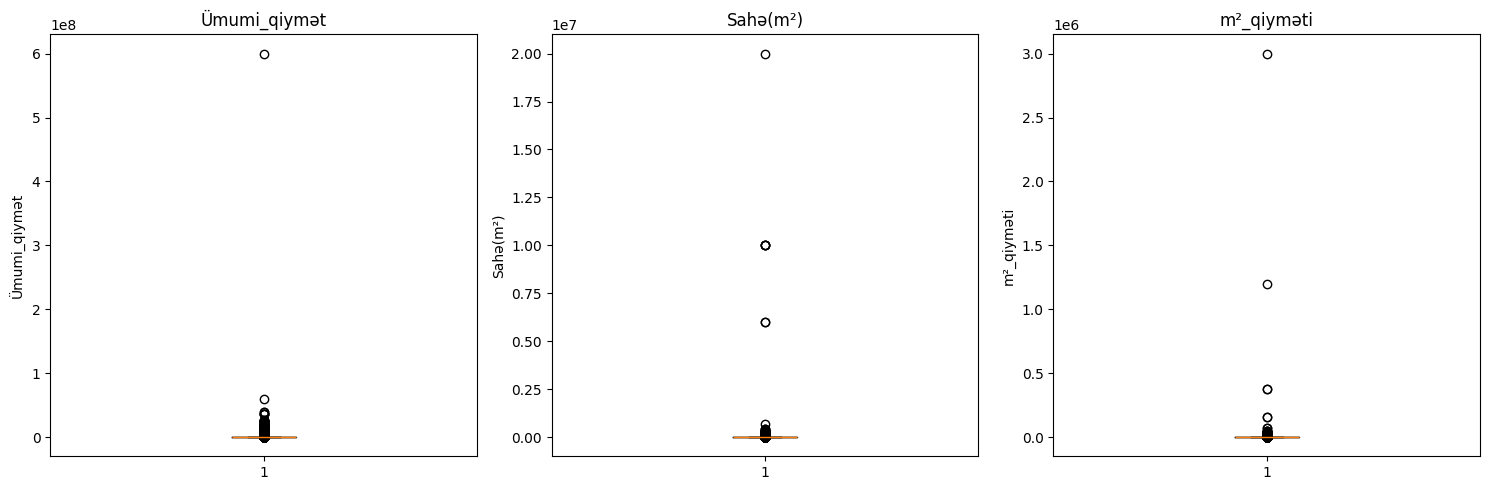

In [85]:
columns = ['Ümumi_qiymət', 'Sahə(m²)', 'm²_qiyməti']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, columns):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## `Ümumi qiymət`

In [86]:
Q1 = df['Ümumi_qiymət'].quantile(0.25)
Q3 = df['Ümumi_qiymət'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Aşağı sərhəd: {lower}")
print(f"Yuxarı sərhəd: {upper}")

Aşağı sərhəd: -144500.0
Yuxarı sərhəd: 627500.0


627 500 AZN-dən yuxarı olan bütün elanlar IQR metoduna görə outlier hesab olunur. Aşağı sərhəd mənfi çıxdığı üçün aşağı tərəfdə outlier yoxdur (qiymət mənfi ola bilməz).

Outlierlərin sayına baxaq:

In [87]:
price_outliers = df[df['Ümumi_qiymət'] > upper]
print(price_outliers.shape)

(7322, 45)


Datasetin ümumilikdə 100 000 sətirlik olduğunu nəzərə alsaq ümumi qiymət üzrə təxminən 7% outlier dəyər mövcuddur.

In [88]:
from scipy.stats import zscore

df['price_zscore'] = zscore(df['Ümumi_qiymət'])
z_outliers = df[abs(df['price_zscore']) > 3]

print("Z-score outlier sayı:", z_outliers.shape[0])
print("Z-score outlier faizi:", round(len(z_outliers) / len(df) * 100, 2), "%")

Z-score outlier sayı: 247
Z-score outlier faizi: 0.25 %


In [89]:
print("IQR outlier sayı:", len(price_outliers))
print("Z-score outlier sayı:", len(z_outliers))

IQR outlier sayı: 7322
Z-score outlier sayı: 247


Ümumi_qiymət dəyişəninin paylanması sağa meyilli olduğundan IQR və Z-score metodları əhəmiyyətli dərəcədə fərqli sayda outlier müəyyən etmişdir. IQR metodu ~7,000 müşahidə, Z-score isə yalnız 247 müşahidə müəyyən etmişdir. Sağ meyillilik və ekstremal qiymətlərin standart kənarlaşmanı artırması səbəbindən Z-score metodunun bu datasetdə daha az həssas olduğu müşahidə edilmişdir. Buna görə outlier aşkarlanmasında IQR nəticələri əsas götürülmüş, lakin IQR ilə müəyyən edilən bütün müşahidələr avtomatik olaraq silinməmişdir.

In [90]:
print("Skewness:", df["Ümumi_qiymət"].skew())

Skewness: 252.30716360987526


Ümumi_qiymət dəyişəninin paylanması yoxlanılmış və skewness göstəricisinin 252.31 olduğu müəyyən edilmişdir. Bu dəyişənin çox güclü sağa meyilli paylanmaya malik olduğunu göstərir. Outlier aşkarlanması üçün həm IQR, həm də Z-score metodları müqayisə edilmişdir. IQR metodu ilə 7,000-dən çox müşahidə outlier kimi müəyyən edilərkən, Z-score (|z| > 3) metodu yalnız 247 müşahidəni (0.25%) outlier kimi müəyyən etmişdir. Bu ciddi fərqin əsas səbəblərindən biri qiymət dəyişəninin güclü sağa meyilli olmasıdır. Z-score orta və standart kənarlaşmaya əsaslandığı üçün yüksək qiymətli ekstremal müşahidələr standart kənarlaşmanı artırır və nəticədə digər yüksək qiymətli müşahidələrin Z-score üzrə outlier kimi müəyyən edilməsini çətinləşdirir. IQR isə kvartillərə əsaslandığından bu paylanmada daha həssas nəticə vermişdir. Buna görə outlier-lərin ilkin aşkarlanmasında IQR metodu əsas götürülmüşdür.

Outlier dəyərlərə daha yaxından baxaq:

In [91]:
price_outliers[['Ümumi_qiymət', 'Kateqoriya', 'Binanın növü', 'Sahə(m²)']].head(20)

,Ümumi_qiymət,Kateqoriya,Binanın növü,Sahə(m²)
5,650000.0,Köhnə tikili,Ev / Mənzil,130.0
8,3000000.0,Obyekt,Biznes mərkəzi,485.0
10,1050000.0,Obyekt,Biznes mərkəzi,360.0
20,770000.0,Yeni tikili,Ev / Mənzil,230.6
27,680000.0,Yeni tikili,Ev / Mənzil,260.0
35,1550000.0,Torpaq,Digər,5030.0
105,640000.0,Həyət evi/Bağ evi,Villa,260.0
106,780000.0,Həyət evi/Bağ evi,Villa,450.0
109,680000.0,Həyət evi/Bağ evi,Villa,300.0
120,850000.0,Obyekt,Biznes mərkəzi,150.0


Ümumi olaraq baxdıqda yüksək qiymətli əmlakların yeni tikililər, villalar, kommersiya obyektləri və ya böyük torpaq sahələri olduğu müşahidə olunur. Birazda araşdıraq:

In [92]:
price_outliers['Kateqoriya'].value_counts()

,count
Kateqoriya,
Yeni tikili,2438
Həyət evi/Bağ evi,1936
Obyekt,1898
Torpaq,864
Köhnə tikili,129
Ofis,56
Qaraj,1


Bu nəticə göstərir ki, IQR tərəfindən outlier kimi müəyyən edilən yüksək qiymətlər yalnız müəyyən bir məlumat səhvindən yaranmır və müxtəlif real əmlak növlərini əhatə edir.

In [93]:
price_outliers['Sahə(m²)'].describe()

,Sahə(m²)
count,7.322000e+03
mean,7.387304e+03
std,2.544102e+05
min,9.000000e+00
25%,2.200000e+02
50%,3.500000e+02
75%,6.500000e+02
max,2.000000e+07


Sahə(m²) dəyişəninin medianı 350 m², 75%-lik kvartili 650 m², maksimumu isə 20,000,000 m² olmuşdur ki, bu da iri torpaq sahələri və kommersiya obyektlərinin mövcudluğunu göstərir.

Bütün statistik outlier-lərin silinməsi və ya IQR sərhədində capping edilməsi real yüksək dəyərli əmlakların məlumatlarının təhrif olunmasına səbəb ola bilər. Məsələn, yuxarı IQR sərhədinin 627,500 AZN olması nəzərə alınarsa, bu həddən yüksək olan real villa, obyekt və ya torpaq elanlarının qiymətini avtomatik olaraq 627,500 AZN-ə endirmək düzgün olmazdı. Buna görə IQR outlier-ləri avtomatik olaraq silə bilmərik.

In [94]:
df.nlargest(10,'Ümumi_qiymət')[['Ümumi_qiymət', 'Kateqoriya', 'Binanın növü', 'Sahə(m²)']]

,Ümumi_qiymət,Kateqoriya,Binanın növü,Sahə(m²)
6605,600000000.0,Yeni tikili,Ev / Mənzil,200.0
6942,60000000.0,Yeni tikili,Ev / Mənzil,50.0
45825,40000000.0,Torpaq,Digər,20000000.0
72637,39000000.0,Torpaq,Digər,20000.0
8065,36000000.0,Obyekt,Biznes mərkəzi,3000.0
31276,36000000.0,Obyekt,Biznes mərkəzi,3000.0
34851,36000000.0,Obyekt,Biznes mərkəzi,3000.0
81161,36000000.0,Obyekt,Biznes mərkəzi,3000.0
69308,26000000.0,Torpaq,Digər,6000000.0
84337,26000000.0,Torpaq,Digər,130000.0


600 milyon AZN, 200 m² mənzil → sahə kiçik, qiymət böyük.

60 milyon AZN, 50 m² mənzil → sahə kiçik, qiymət böyük.

Digər 40 milyon AZN, 20 milyon m² əmlakı sahənin outlierlərini hesablayanda araşdırılacaq. İndi isə bu iki outlieri daha da dərindən araşdıraq:

In [95]:
df.loc[
    df['Ümumi_qiymət'].isin([600000000, 60000000]),
    ['Ümumi_qiymət', 'Sahə(m²)', 'm²_qiyməti', 'Kateqoriya', 'Təsvir']
]

,Ümumi_qiymət,Sahə(m²),m²_qiyməti,Kateqoriya,Təsvir
6605,600000000.0,200.0,3000000.0,Yeni tikili,Əlavə olunmayıb
6942,60000000.0,50.0,1200000.0,Yeni tikili,Dom


200 m² yeni tikili mənzilin 600 milyon AZN olması bazar reallığı ilə uyğun gəlmir. 50 m² mənzilin 60 milyon AZN olması da eyni dərəcədə qeyri-realdır.
m² qiymətləri də (3 000 000 və 1 200 000 AZN/m²) bazardakı normal diapazondan çox uzaqdır. Təsvirlər də çox informativ deyil ("Əlavə olunmayıb", "Dom"), bu da məlumatın etibarlılığına əlavə dəstək vermir.

In [96]:
df = df[~df['Ümumi_qiymət'].isin([600000000, 60000000])]

200 m² sahəsi olan mənzilin 600 milyon AZN və 50 m² sahəsi olan mənzilin 60 milyon AZN qiymətlə təqdim edildiyi elanlar məlumat xətası kimi qiymətləndirilmiş və datasetdən çıxarılmışdır. Digər yüksək qiymətli elanlar isə villa, iri torpaq sahəsi və kommersiya obyektlərinə aid olduğundan saxlanılmışdır.

## `Sahə(m²)`

In [97]:
Q1 = df['Sahə(m²)'].quantile(0.25)
Q3 = df['Sahə(m²)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Aşağı sərhəd:", lower)
print("Yuxarı sərhəd:", upper)

Aşağı sərhəd: -65.0
Yuxarı sərhəd: 295.0


295 m²-dan yuxarı olan bütün elanlar IQR metoduna görə outlier hesab olunur. Aşağı sərhəd mənfi çıxdığı üçün aşağı tərəfdə outlier yoxdur (sahə mənfi ola bilməz).

In [98]:
area_outliers = df[df['Sahə(m²)'] > upper]
print(area_outliers.shape)

(10265, 46)


Datasetin ümumilikdə 100 000 sətirlik olduğunu nəzərə alsaq sahə üzrə təxminən 10% outlier dəyər mövcuddur.

In [99]:
from scipy.stats import zscore

df['area_zscore'] = zscore(df['Sahə(m²)'])
area_z_outliers = df[abs(df['area_zscore']) > 3]

print("IQR outlier sayı:", len(area_outliers))
print("Z-score outlier sayı:", len(area_z_outliers))
print("Z-score outlier faizi:",round(len(area_z_outliers) / len(df) * 100, 2),"%")

IQR outlier sayı: 10265
Z-score outlier sayı: 17
Z-score outlier faizi: 0.02 %


IQR metodu ilə 10,265 müşahidə outlier kimi müəyyən edilərkən, Z-score (|z| > 3) metodu yalnız 17 müşahidəni (0.02%) outlier kimi müəyyən etmişdir. İki metod arasındakı ciddi fərq dəyişənin paylanmasının güclü sağa meyilli olması ilə əlaqələndirilmişdir. Z-score orta və standart kənarlaşmaya əsaslandığından ekstremal sahə dəyərlərinin standart kənarlaşmanı artırması nəticəsində daha az müşahidəni outlier kimi müəyyən edir. IQR isə kvartillərə əsaslandığından bu tip paylanmalarda daha çox müşahidəni potensial outlier kimi işarələyir.

In [100]:
print("Skewness:", df['Sahə(m²)'].skew())

Skewness: 152.35288362673984


Bu nəticə dəyişənin çox güclü sağa meyilli paylanmaya malik olduğunu göstərir. Outlier aşkarlanması üçün IQR və Z-score metodları müqayisə edilmişdir. IQR metodu ilə 10,265 müşahidə (təxminən 10.18%), Z-score (|z| > 3) metodu ilə isə yalnız 17 müşahidə (0.02%) outlier kimi müəyyən edilmişdir. Metodlar arasındakı böyük fərq əsasən dəyişənin güclü sağa meyilli olması ilə əlaqələndirilir. Z-score orta və standart kənarlaşmaya əsaslandığından ekstremal sahə dəyərləri standart kənarlaşmanı əhəmiyyətli dərəcədə artırır və nəticədə Z-score metodu daha az müşahidəni outlier kimi müəyyən edir. IQR kvartillərə əsaslandığı üçün bu paylanmada daha çox ekstremal müşahidəni müəyyən etmişdir. Buna görə outlier-lərin ilkin aşkarlanmasında IQR metodu əsas götürülmüşdür.

In [101]:
df.nlargest(10,'Sahə(m²)')[['Sahə(m²)', 'Ümumi_qiymət', 'Kateqoriya', 'Binanın növü', 'Məkan']]

,Sahə(m²),Ümumi_qiymət,Kateqoriya,Binanın növü,Məkan
45825,20000000.0,40000000.0,Torpaq,Digər,28 May m.
4736,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.
9746,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.
21517,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.
75857,10000000.0,3000.0,Torpaq,Digər,Fatmayı q.
28995,6000000.0,19000000.0,Torpaq,Digər,Binəqədi r.
69308,6000000.0,26000000.0,Torpaq,Digər,Binəqədi r.
172,700000.0,80000.0,Torpaq,Digər,Maştağa q.
87428,440000.0,2640000.0,Torpaq,Digər,Qobu q.
3348,400000.0,3500.0,Torpaq,Digər,Buzovna q.


20 000 000 m² sahə,	40 000 000 AZN 	→ 20 milyon m² (2000 hektar) çox böyük sahədir.

10 000 000 m² sahə,	2 500	AZN → 10 milyon m² torpağın cəmi 2500 AZN olması iqtisadi baxımdan real deyil.

10 000 000 m² sahə,	3 000	AZN →  10 milyon m² torpağın cəmi 3000 AZN olması iqtisadi baxımdan real deyil.

6 000 000 m² sahə,	19 000 000 AZN	→ 6 milyon m² (600 hektar) çox böyük sahədir.

6 000 000	m² sahə, 26 000 000	AZN →  6 milyon m² (600 hektar) çox böyük sahədir.

400 000 m² sahə, 3500 AZN	→ 400 000 m² torpağın 3500 AZN olması iqtisadi baxımdan real deyil.

Sahəsi böyük olan sütunların reallığı araşdırılmalıdır, amma digərləri iqtisadi baxımdan doğru hesab olunmadığı üçün silinəcək.

In [102]:
df.loc[df['Sahə(m²)'].isin([20000000, 6000000]),['Sahə(m²)', 'Ümumi_qiymət', 'Təsvir']]

,Sahə(m²),Ümumi_qiymət,Təsvir
28995,6000000.0,19000000.0,Binəqədi rayonunda 6 hektar torpaq sahəsisatil...
45825,20000000.0,40000000.0,Torpaq 2 hektardi sehere denize gozel menzeres...
69308,6000000.0,26000000.0,Binəqədi rayonunda 6 hektar torpaq sahəsisatil...


Təsvir sütununa diqqət etdikdə görürük ki, sahələr hektarla verilib 1 hektar = 10 000 m² olduğunu nəzərə alsaq sahə sütununda göstərilən dəyər ilə təsvirdəki dəyərdə məlumat uyğunsuzluğu var. Onları tam düzgün versiyaya gətirək və outlierləri bərpa edək:

In [103]:
# 1 hektar = 10 000 m²
df['Sahə(m²)'] = df['Sahə(m²)'].replace({
    6000000: 60000,
    20000000: 20000
})

Digər outlier hesab etdiyimiz dəyərləri də bu qayda ilə araşdıraq:

In [104]:
df.nlargest(10,'Sahə(m²)')[['Sahə(m²)', 'Ümumi_qiymət', 'Kateqoriya', 'Binanın növü', 'Məkan','Təsvir']]

,Sahə(m²),Ümumi_qiymət,Kateqoriya,Binanın növü,Məkan,Təsvir
4736,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.,\n🆘Torpaq sahesi 1 hektardi (ha) \n🆘Torpagi qa...
9746,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.,\n🆘Torpaq sahesi 1 hektardi (ha) \n🆘Torpagi qa...
21517,10000000.0,2500.0,Torpaq,Digər,Fatmayı q.,\n🆘Torpaq sahesi 1 hektardi (ha) \n🆘Torpagi qa...
75857,10000000.0,3000.0,Torpaq,Digər,Fatmayı q.,…\n🆘Torpaq sahesi 1 hektardi (ha) \n🆘Torpagi q...
172,700000.0,80000.0,Torpaq,Digər,Maştağa q.,Salam..Ərazi magistral yolda yerləşir...məktəb...
87428,440000.0,2640000.0,Torpaq,Digər,Qobu q.,Abşeron Rayonu Qobu Qesebesi Sevil Massivi.\n4...
3348,400000.0,3500.0,Torpaq,Digər,Buzovna q.,"Çox təcili və dəyərindən ucuz qiymətə 4,2hek..."
37618,400000.0,16000000.0,Torpaq,Digər,Lökbatan q.,⛔️ XAHİŞ OLUNUR VASİTƏÇİLƏR NARAHAT ETMƏSİNLƏR...
75936,350000.0,30000.0,Torpaq,Digər,Xaçmaz,Torpaqin sənətləri tamdır ekin ve baq ucun elv...
99064,340000.0,11000000.0,Torpaq,Digər,Binəqədi q.,Binəqədi əsas yolun kənarında yerləşir\nSənədl...


Araşdırdıqda yenə məlumat uyğunsuzluğu olduğunu müşahidə edirik, hektarları düzgün şəkildə çevirək:

In [105]:
# 1 hektar = 10 000 m²
df.loc[[4736, 9746, 21517, 75857], 'Sahə(m²)'] = 10000

df.loc[3348, 'Sahə(m²)'] = 42000

Outlier dəyərləri araşdırarkən bu dəyərlərin əslində səhv çevrilmiş sahə sütunundan irəli gəldiyi aşkar edildi. Təsvir sütunundakı məlumatlara əsasən hektarla ifadə olunan dəyəri sahəyə çevirərək outlier dəyərləri bərpa etdik.

In [106]:
area_outliers["Kateqoriya"].value_counts()

,count
Kateqoriya,
Torpaq,4669
Həyət evi/Bağ evi,3667
Obyekt,1268
Yeni tikili,593
Ofis,36
Köhnə tikili,31
Qaraj,1


IQR ilə müəyyən edilən 10,265 outlier-in 4,669-u Torpaq, 3,667-si Həyət evi/Bağ evi və 1,268-i Obyekt kateqoriyasına aiddir. Bu üç kateqoriya birlikdə outlier-lərin böyük əksəriyyətini təşkil edir. Bu nəticə göstərir ki, yüksək sahə dəyərlərinin əhəmiyyətli hissəsi təsadüfi məlumat səhvindən deyil, torpaq, həyət evi və kommersiya obyektləri kimi təbii olaraq daha böyük sahəyə malik əmlaklardan qaynaqlana bilər.

In [107]:
area_outliers["Sahə(m²)"].describe()

,Sahə(m²)
count,1.026500e+04
mean,1.011145e+04
std,2.918861e+05
min,2.960000e+02
25%,4.000000e+02
50%,6.000000e+02
75%,1.200000e+03
max,2.000000e+07


Outlier qrupunda median sahənin 600 m², 75%-lik kvartilin isə 1,200 m² olması da bu müşahidələrin hamısının qeyri-real olmadığını göstərir.

Buna görə IQR ilə müəyyən edilən bütün outlier-lər silinməmiş və capping/winsorization tətbiq edilməmişdir. Çünki bütün yüksək sahələri IQR-in yuxarı sərhədinə endirmək real torpaq və əmlak sahələrini süni şəkildə dəyişdirərdi. Bunun əvəzinə, ekstremal dəyərlər ayrıca yoxlanılmış və yalnız məlumat daxil etmə və vahid çevirmə səhvi olduğu müəyyən edilən müşahidələrə müdaxilə edilmişdir.

## `m²_qiyməti`

In [108]:
Q1 = df['m²_qiyməti'].quantile(0.25)
Q3 = df['m²_qiyməti'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Aşağı sərhəd:", lower)
print("Yuxarı sərhəd:", upper)

Aşağı sərhəd: 97.07317073170702
Yuxarı sərhəd: 4309.756097560976


97 AZN/m²-dan yuxarı olan bütün elanlar IQR metoduna görə aşağı outlier, 4309 AZN/m²-dən yuxarı olanlar isə yüksək outlier hesab olunur.

Outlierlərin sayına baxaq:

In [109]:
m2_outliers = df[
    (df['m²_qiyməti'] < lower) |
    (df['m²_qiyməti'] > upper)
]

m2_outliers.shape

(5240, 47)

Datasetin ümumilikdə 100 000 sətirlik olduğunu nəzərə alsaq sahə üzrə təxminən 5% outlier dəyər mövcuddur.

In [110]:
from scipy.stats import zscore

df['m2_zscore'] = zscore(df['m²_qiyməti'])
m2_z_outliers = df[abs(df['m2_zscore']) > 3]

print("IQR outlier sayı:", len(m2_outliers))
print("Z-score outlier sayı:", len(m2_z_outliers))
print("Z-score outlier faizi:",round(len(m2_z_outliers) / len(df) * 100, 2),"%")

IQR outlier sayı: 5240
Z-score outlier sayı: 500
Z-score outlier faizi: 0.5 %


m²_qiyməti dəyişənində IQR və Z-score metodları müqayisə edilmişdir. IQR metodu 5,242 müşahidəni, Z-score (|z| > 3) metodu isə yalnız 20 müşahidəni (0.02%) outlier kimi müəyyən etmişdir. IQR və Z-score nəticələri arasındakı ciddi fərq dəyişənin paylanmasının xüsusiyyətləri ilə əlaqədardır. Buna görə paylanmanın skewness göstəricisi əlavə olaraq yoxlayaq:

In [111]:
print("Skewness:", df["m²_qiyməti"].skew())

Skewness: 94.31457488780856


m²_qiyməti dəyişəninin skewness göstəricisi 251.69 olmuşdur ki, bu da dəyişənin çox güclü sağa meyilli paylanmaya malik olduğunu göstərir. IQR və Z-score metodları müqayisə edilmişdir. IQR metodu 5,242 müşahidəni, Z-score (|z| > 3) metodu isə yalnız 20 müşahidəni (0.02%) outlier kimi müəyyən etmişdir. Bu metodlar arasındakı böyük fərq dəyişənin güclü sağa meyilli olması ilə əlaqələndirilir. Z-score orta və standart kənarlaşmaya əsaslandığından ekstremal qiymətlər standart kənarlaşmanı artırır və nəticədə daha az müşahidə outlier kimi müəyyən edilir. IQR isə kvartillərə əsaslandığından bu tip paylanmada daha çox ekstremal müşahidəni müəyyən edir. Buna görə ilkin outlier aşkarlanmasında IQR metodu əsas götürülmüşdür.

In [112]:
df.nlargest(10, 'm²_qiyməti')[['m²_qiyməti', 'Ümumi_qiymət', 'Sahə(m²)', 'Kateqoriya', 'Binanın növü', 'Məkan']]

,m²_qiyməti,Ümumi_qiymət,Sahə(m²),Kateqoriya,Binanın növü,Məkan
12285,380000.000000,380000.0,1.0,Həyət evi/Bağ evi,Villa,Şüvəlan q.
16168,380000.000000,380000.0,1.0,Həyət evi/Bağ evi,Villa,Şüvəlan q.
9096,159482.758621,18500000.0,116.0,Obyekt,Biznes mərkəzi,Sahil m.
14281,159482.758621,18500000.0,116.0,Obyekt,Biznes mərkəzi,Sahil m.
11364,72222.222222,650000.0,9.0,Həyət evi/Bağ evi,Villa,Azadlıq Prospekti m.
15638,72222.222222,650000.0,9.0,Həyət evi/Bağ evi,Villa,Azadlıq Prospekti m.
34426,51020.408163,5000000.0,98.0,Obyekt,Biznes mərkəzi,Sahil m.
98699,51020.408163,5000000.0,98.0,Obyekt,Biznes mərkəzi,Sahil m.
75798,51000.000000,5100000.0,100.0,Obyekt,Biznes mərkəzi,Sahil m.
98693,49494.949495,4900000.0,99.0,Obyekt,Biznes mərkəzi,Sahil m.


In [113]:
df.loc[df['m²_qiyməti'].isin([380000]),['m²_qiyməti', 'Sahə(m²)', 'Ümumi_qiymət', 'Təsvir']]

,m²_qiyməti,Sahə(m²),Ümumi_qiymət,Təsvir
12285,380000.0,1.0,380000.0,Salam Suvalanda Esas yola Yaxin 4 Sot Moderin ...
16168,380000.0,1.0,380000.0,Salam Suvalanda Esas yola Yaxin 4 Sot Moderin ...


Təsvir sütununa baxdıqda torpağın 4 sot qeyd olunduğunu görürük, sahə sütunu ilə təsvir sütunu arasında məlumat uyğunsuzluğu var. Uyğunsuzluğu aradan qaldıraq:

In [114]:
# 1 ot = 100 m²
df.loc[[16168,12285], 'Sahə(m²)'] = 400.0

In [115]:
df.loc[[16168, 12285], 'Sahə(m²)'] = 400

df.loc[[16168, 12285], 'm²_qiyməti'] = (
    df.loc[[16168, 12285], 'Ümumi_qiymət'] /
    df.loc[[16168, 12285], 'Sahə(m²)']
)

Həm sahənin qiymətini, həm də m²_qiymətini də ayrıca sahəyə uyğun dəyişdik.



In [116]:
df.loc[df['Sahə(m²)'].isin([9.0]),['m²_qiyməti', 'Sahə(m²)', 'Ümumi_qiymət', 'Təsvir']]

,m²_qiyməti,Sahə(m²),Ümumi_qiymət,Təsvir
11364,72222.222222,9.0,650000.0,"Binəqədi r-nu , RƏSULZADƏ qəsəbəsi,AZADLIQ met..."
15638,72222.222222,9.0,650000.0,"Binəqədi r-nu , RƏSULZADƏ qəsəbəsi,AZADLIQ met..."
68330,3280.000000,9.0,29500.0,Mikro-mənzil satılır!!! -Bina.\nArtıq dünyanın...


Təsvir sütununa baxdıqda torpağın 9 sot qeyd olunduğunu görürük, sahə sütunu ilə təsvir sütunu arasında məlumat uyğunsuzluğu var. Uyğunsuzluğu aradan qaldıraq:

In [117]:
# 1 ot = 100 m²
df.loc[[11364,15638], 'Sahə(m²)'] = 900

In [118]:
df.loc[[11364,15638], 'm²_qiyməti'] = (
    df.loc[[11364,15638], 'Ümumi_qiymət'] /
    df.loc[[11364,15638], 'Sahə(m²)']
)

Həm sahənin qiymətini, həm də m²_qiymətini də ayrıca sahəyə uyğun dəyişdik.

Outlier dəyərləri araşdırarkən bu dəyərlərin əslində səhv çevrilmiş sahə sütunundan irəli gəldiyi aşkar edildi. Təsvir sütunundakı məlumatlara əsasən sotla ifadə olunan dəyəri sahəyə çevirdik və m²_qiymətini buna uyğunlaşdıraraq outlier dəyərləri bərpa etdik.

In [119]:
m2_outliers["Kateqoriya"].value_counts()

,count
Kateqoriya,
Torpaq,1884
Obyekt,1566
Yeni tikili,1325
Köhnə tikili,274
Həyət evi/Bağ evi,147
Ofis,44


m²_qiyməti üzrə IQR metodu ilə müəyyən edilən 5,242 outlier-in 4,777-si (91.1%) Torpaq, Obyekt və Yeni tikili kateqoriyalarına aiddir. Bu kateqoriyalarda m² qiymətlərinin geniş diapazonda dəyişməsi əmlakın yerləşməsi, təyinatı, tikinti xüsusiyyətləri və bazar dəyəri ilə əlaqəli ola bilər. Buna görə statistik olaraq outlier hesab edilən hər bir müşahidəni səhv məlumat kimi qəbul etmək düzgün deyil. Bu səbəbdən outlier-lər avtomatik olaraq silinməmiş və capping/winsorization tətbiq edilməmişdir. Yalnız təsviri məlumatlar və digər dəyişənlərlə müqayisə zamanı açıq məlumat daxil etmə səhvi olduğu müəyyən edilən müşahidələrə müdaxilə edilmişdir.

# Vizuallaşdırma

In [120]:
binary_columns = ['Çıxarış', 'İpoteka', 'VIP', 'Önə_çəkilmiş']
mapping = {
    'var': 1,
    'yoxdur': 0
}

df[binary_columns] = df[binary_columns].replace(mapping).astype(int)
df['Təmir'] = df['Təmir'].replace({'var': 1, 'yoxdur': 0})

/tmp/ipykernel_723/556619316.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_columns] = df[binary_columns].replace(mapping).astype(int)


Çıxarış, İpoteka, Təmir, VIP, Önə_çəkilmiş sütunlarında binary kateqorik dəyərlər olduğu üçün onları 0 və 1 şəklində ifadə edə bilərik. Lakin təmir sütununda NaN dəyərləri "məlum deyil" ifadəsi ilə doldurduğumuz üçün onu int data tipində ifadə edə bilmirik,ona görə də onu ayrıca əvəz etdik.

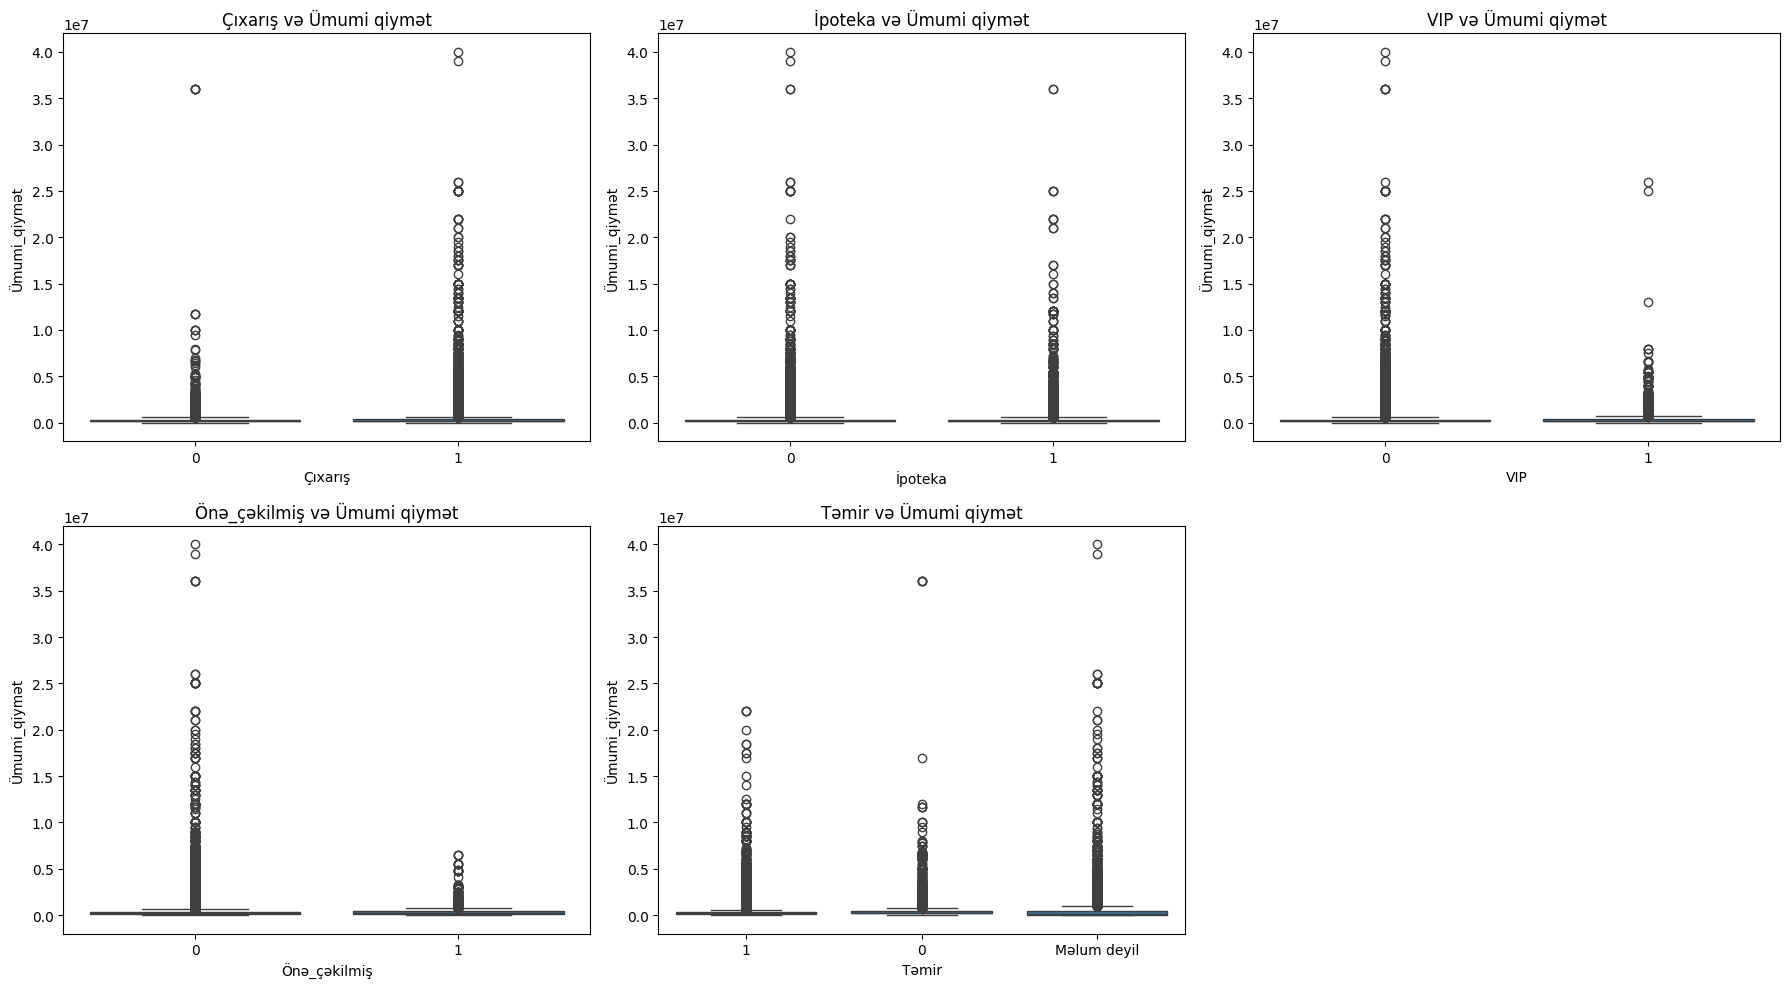

In [121]:
# Ümumi qiymətin paylanması (Boxplot)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cols = ['Çıxarış', 'İpoteka', 'VIP', 'Önə_çəkilmiş', 'Təmir']

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(
        data=df,
        x=col,
        y='Ümumi_qiymət',
        ax=ax
    )
    ax.set_title(f'{col} və Ümumi qiymət')
fig.delaxes(axes[1,2])
plt.tight_layout()
plt.show()

Çıxarışı olan əmlaklarda qiymət diapazonu daha genişdir və yüksək qiymətli elanlar daha çox bu qrupa aiddir. İpoteka, VIP və önə çəkilmiş statuslarının qiymətə təsiri zəif müşahidə olunur, çünki bu xüsusiyyətlərə malik və malik olmayan elanların qiymət paylanmaları böyük ölçüdə oxşardır. Təmirli əmlakların isə ümumilikdə daha yüksək qiymətə malik olduğu görünür. Həmçinin bütün qrafiklərdə çoxsaylı outlier-lərin mövcud olması datasetdə yüksək qiymətli villa, torpaq və biznes mərkəzləri kimi əmlakların yer alması ilə izah olunur.

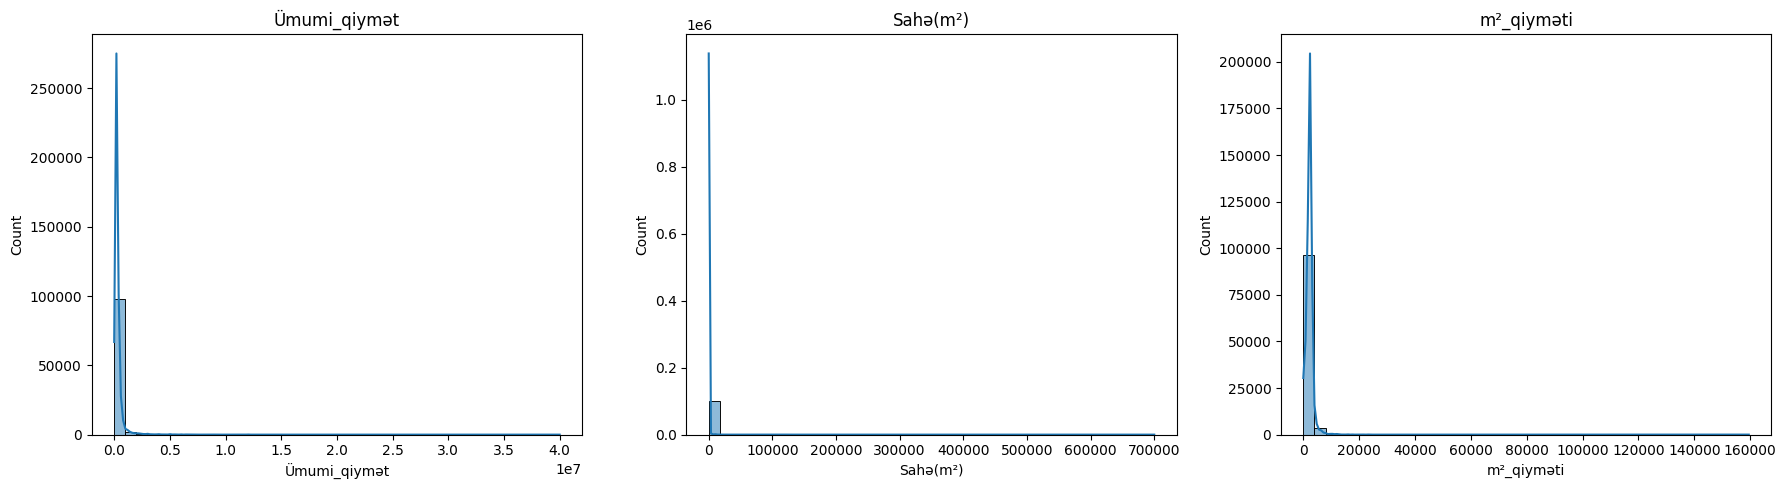

In [122]:
# Ümumi qiymət, Sahə(m²) və m² qiymətinin paylanması
columns = ['Ümumi_qiymət', 'Sahə(m²)', 'm²_qiyməti']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, columns):
    sns.histplot(
        data=df,
        x=col,
        bins=40,
        kde=True,
        ax=ax
    )
    ax.set_title(col)
plt.tight_layout()
plt.show()

Ümumi qiymət, Sahə(m²) və m² qiyməti sütunlarının paylanmaları sağa meyllidir (right-skewed). Müşahidələrin böyük hissəsi aşağı qiymətlərdə və kiçik sahələrdə cəmləşmiş, az sayda çox böyük dəyərlər isə uzun sağ quyruq (long right tail) yaratmışdır. Bu vəziyyət datasetdə çoxsaylı outlier-lərin mövcud olduğunu göstərir və məlumatların normal paylanmadığını göstərir. Buna görə də sonrakı analizdə log transformasiyası ilə normala yaxın versiyaya baxaq. Çünki əmlaklar müxtəlif kateqoriyalara aiddir və istər sahə, istərsə də qiymət baxımından fərqlənə bilir.

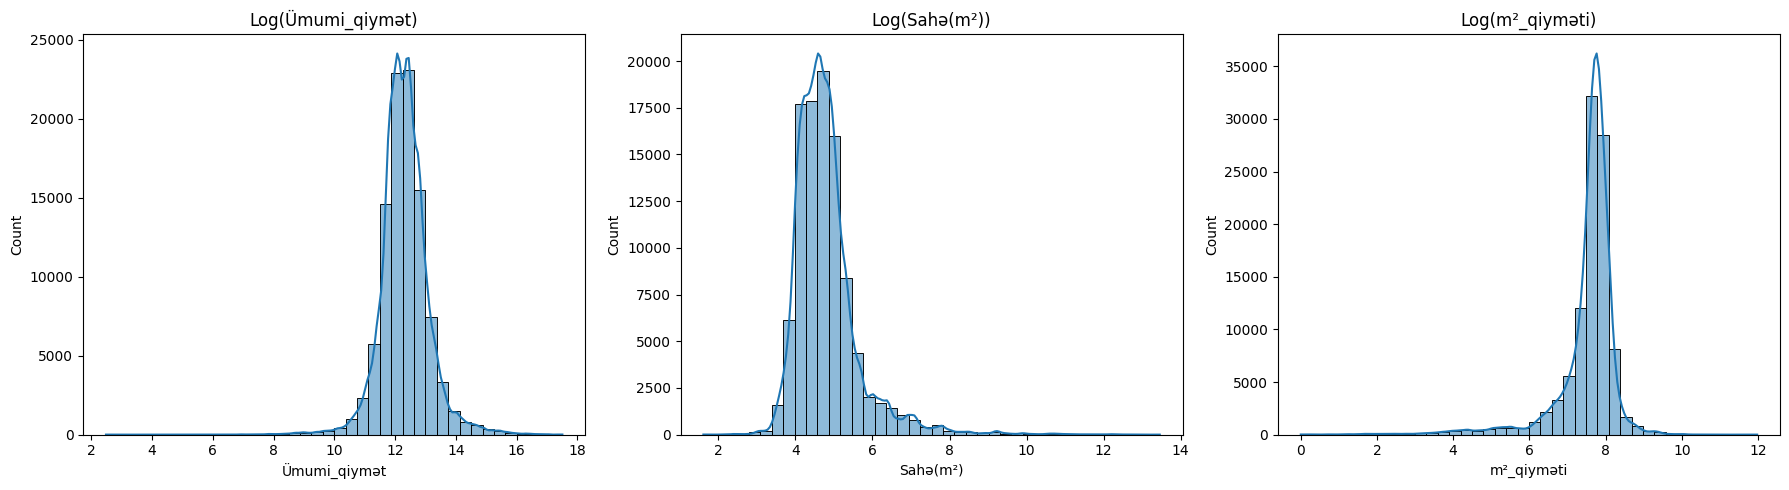

In [123]:
# Log transformasiyasından sonra Ümumi qiymət, Sahə(m²) və m² qiymətinin paylanması
columns = ['Ümumi_qiymət', 'Sahə(m²)', 'm²_qiyməti']

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, col in zip(axes, columns):
    sns.histplot(
        np.log1p(df[col]),
        bins=40,
        kde=True,
        ax=ax
    )
    ax.set_title(f'Log({col})')
plt.tight_layout()
plt.show()

Log transformasiyasından sonra Ümumi qiymət, Sahə(m²) və m² qiyməti sütunlarının paylanması daha aydın görünür. Ümumi qiymət və m² qiyməti təxminən zəngvari (normala yaxın) paylanma nümayiş etdirsə də, sağ tərəfdə uzun quyruq qalmaqdadır ki, bu da yüksək qiymətli outlier-lərin hələ də mövcud olduğunu göstərir. Sahə(m²) sütunu isə daha çox sağa meyilli paylanmaya malikdir və çox böyük sahəyə sahib azsaylı əmlaklar səbəbindən sağ quyruq daha uzundur. Ümumilikdə, log transformasiyası böyük dəyərlərin təsirini azaltdığı üçün məlumatların əsas hissəsinin paylanmasını daha aydın müşahidə etməyə imkan verir.

Qeyd: Paylanmanın daha aydın görünməsi üçün histogramlarda log transformasiyası (log1p) tətbiq edilmişdir. Bu transformasiya məlumatların nisbi quruluşunu qoruyaraq yüksək outlier-lərin vizuallaşdırmaya təsirini azaldır.

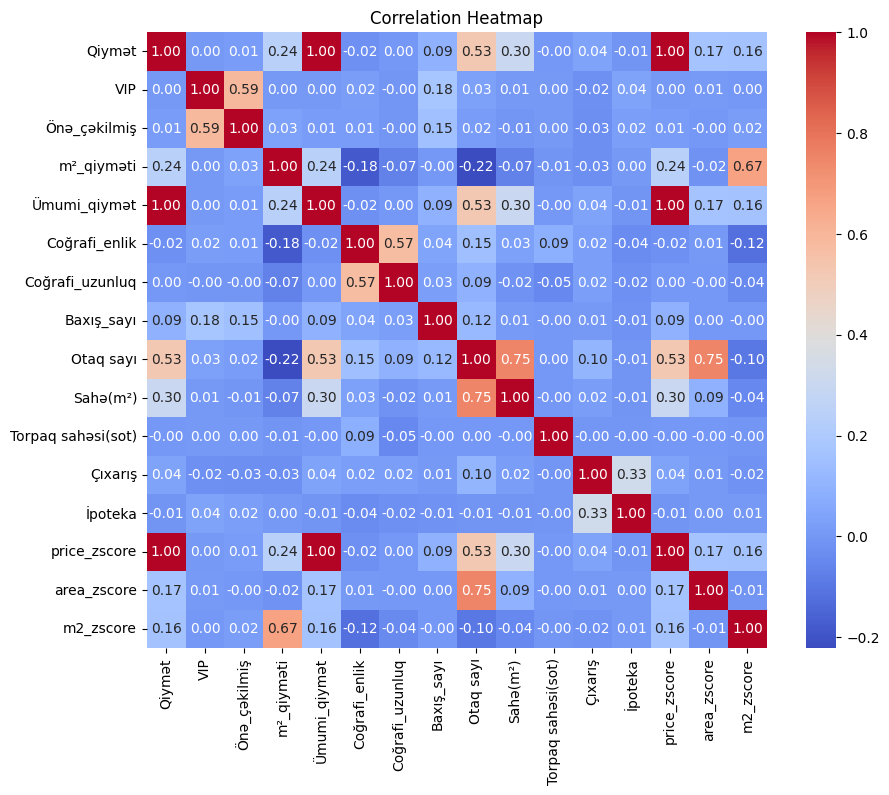

In [124]:
# Korrelyasiya heatmap
numeric = df.select_dtypes(include='number')

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Dəyişənlər arasında ümumilikdə güclü xətti əlaqə yoxdur. Ümumi qiymət ilə Sahə(m²) arasında zəif müsbət korrelyasiya, m² qiyməti ilə isə daha zəif müsbət korrelyasiya müşahidə olunur. Coğrafi enlik və coğrafi uzunluq arasında orta səviyyəli müsbət əlaqə mövcuddur ki, bu da onların coğrafi koordinatlar olmasından irəli gəlir. Çıxarış və İpoteka arasında da orta səviyyəli müsbət korrelyasiya müşahidə edilir və bu, ipotekaya uyğun əmlakların əksəriyyətində çıxarışın olmasını göstərir. Digər dəyişənlər arasında korrelyasiya əmsalları 0-a yaxın olduğundan onların arasında əhəmiyyətli xətti əlaqə müşahidə olunmur.

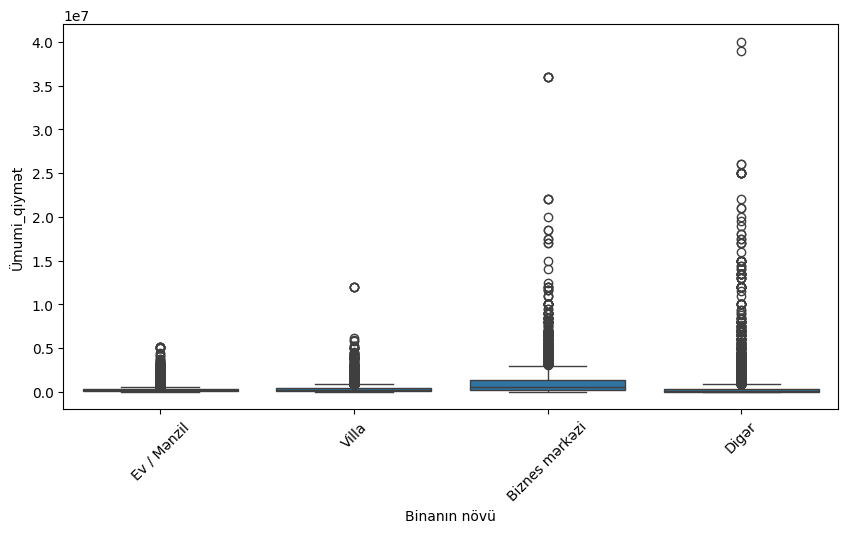

In [125]:
# Binanın növünə görə ümumi qiymətin paylanması (Boxplot)
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='Binanın növü',
    y='Ümumi_qiymət'
)
plt.xticks(rotation=45)
plt.show()

Biznes mərkəzi kateqoriyasına aid obyektlərin median qiyməti digər bina növləri ilə müqayisədə daha yüksəkdir və qiymət diapazonu daha genişdir. Ev/Mənzil və Villa kateqoriyalarında qiymətlər nisbətən aşağı və daha sıx paylanmışdır. Digər kateqoriyasında isə çoxsaylı yüksək qiymətli outlier-lər müşahidə olunur ki, bu da həmin qrupa bahalı torpaq və kommersiya obyektlərinin daxil olması ilə əlaqədardır. Ümumilikdə, bina növünün əmlakın ümumi qiymətinə təsir göstərən əsas amillərdən biri olduğu görünür.

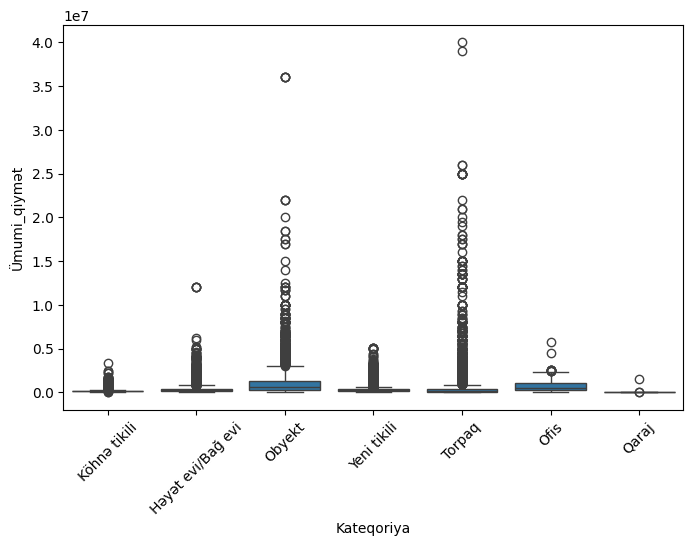

In [126]:
# Əmlak kateqoriyasına görə ümumi qiymətin paylanması (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Kateqoriya',
    y='Ümumi_qiymət'
)
plt.xticks(rotation=45)
plt.show()

Obyekt kateqoriyası digər kateqoriyalarla müqayisədə daha yüksək median qiymətə və daha geniş qiymət diapazonuna malikdir. Torpaq kateqoriyasında median qiymət aşağı olsa da, çoxlu sayda yüksək qiymətli outlier müşahidə olunur ki, bu da böyük və dəyərli torpaq sahələrinin mövcudluğu ilə izah olunur. Ofis kateqoriyasında da qiymətlər nisbətən yüksəkdir, lakin müşahidələrin sayı azdır. Köhnə tikili, Yeni tikili, Həyət evi/Bağ evi və Qaraj kateqoriyalarında qiymətlər daha aşağı diapazonda cəmlənmişdir. Ümumilikdə, əmlakın kateqoriyası onun ümumi qiymətinə əhəmiyyətli təsir göstərən amillərdən biridir.

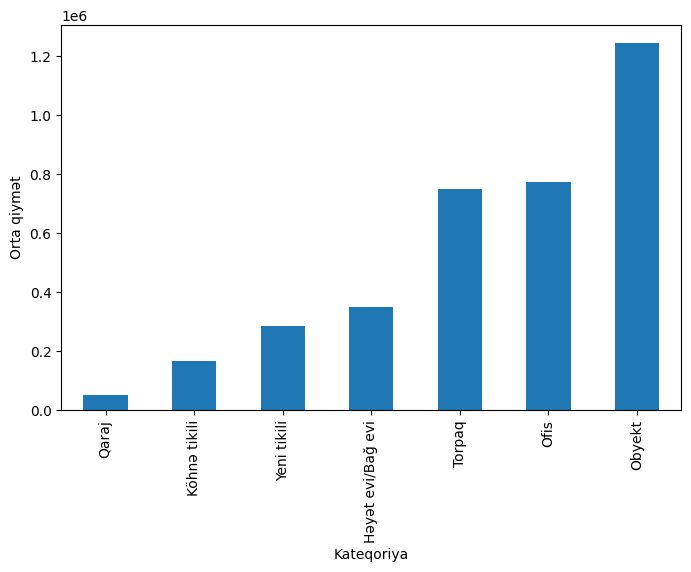

In [127]:
# Əmlak kateqoriyalarına görə orta qiymətin müqayisəsi
mean_price = (df.groupby('Kateqoriya')['Ümumi_qiymət'].mean().sort_values())

mean_price.plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel("Orta qiymət")
plt.show()

Obyekt kateqoriyası ən yüksək orta qiymətə malikdir. Onu Ofis və Torpaq kateqoriyaları izləyir. Həyət evi/Bağ evi və Yeni tikili kateqoriyalarının orta qiymətləri orta səviyyədədir, Köhnə tikili və xüsusilə Qaraj kateqoriyaları isə ən aşağı orta qiymətə malikdir. Ümumilikdə, kommersiya təyinatlı əmlakların yaşayış tipli əmlaklarla müqayisədə daha yüksək orta qiymətə sahib olduğu müşahidə olunur.

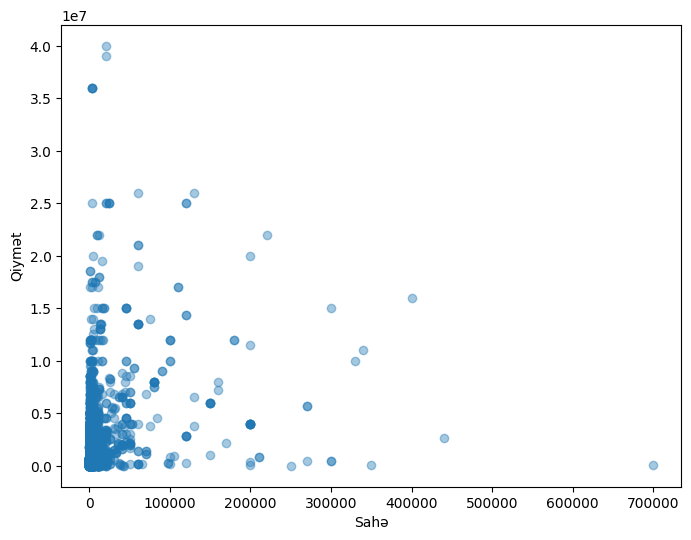

In [128]:
# Sahə ilə qiymət arasındakı əlaqə (Scatter Plot)
plt.figure(figsize=(8,6))
plt.scatter(
    df['Sahə(m²)'],
    df['Ümumi_qiymət'],
    alpha=0.4
)
plt.xlabel("Sahə")
plt.ylabel("Qiymət")
plt.show()

Sahə ilə qiymət arasında zəif müsbət əlaqə mövcuddur. Ümumilikdə sahə artdıqca qiymətin artması müşahidə olunsa da, bu əlaqə xətti deyil və verilənlər geniş şəkildə səpələnmişdir. Kiçik sahəli əmlaklarda həm aşağı, həm də çox yüksək qiymətli elanlar mövcuddur, böyük sahəli əmlaklarda isə nümunə sayı azdır və bir neçə ekstremal qiymət diqqət çəkir. Bu da göstərir ki, əmlakın qiyməti yalnız sahədən deyil, yerləşdiyi məkan, kateqoriya, bina növü və digər xüsusiyyətlərdən də əhəmiyyətli dərəcədə asılıdır.

In [129]:
# Kateqoriyalar üzrə median qiymət
df.groupby("Kateqoriya")["Ümumi_qiymət"].median().sort_values(ascending=False)

,Ümumi_qiymət
Kateqoriya,
Obyekt,589500.0
Ofis,475000.0
Yeni tikili,245000.0
Həyət evi/Bağ evi,235000.0
Torpaq,150000.0
Köhnə tikili,145000.0
Qaraj,30000.0


Kateqoriyalar üzrə median qiymətlər müqayisəsində Obyekt kateqoriyası 589,500 AZN median qiymətlə ən yüksək nəticəni göstərmişdir. Onu Ofis (475,000 AZN) və Yeni tikili (245,000 AZN) kateqoriyaları izləmişdir. Həyət evi/Bağ evi üçün median qiymət 235,000 AZN, Torpaq üçün 150,000 AZN, Köhnə tikili üçün 145,000 AZN, Qaraj üçün isə 30,000 AZN olmuşdur. Bu nəticələr kommersiya təyinatlı əmlakların yaşayış tipli əmlaklarla müqayisədə daha yüksək median qiymətə malik olduğunu göstərir.

## Modelə hazırlıq

In [130]:
drop_cols = [
    "Elan_ID_1",
    "Elan_URL",
    "Əmlak_URL",
    "Elan_ID_2",
    "Əmlak_ID",
    "Detal_ID",
    "Şəkil_URL",
    "Ünvan",
    "price_zscore",
    "area_zscore",
    "m2_zscore",
    "Təsvir",
    "Əlavə_məlumat",
    "Əmlak_xüsusiyyətləri",
    "Sahibin_adı",
    'Qiymət',
    'Valyuta_1',
    'VIP',
    'Önə_çəkilmiş',
    "Elanı_yerləşdirən",
    "Toplanma_tarixi_1",
    "Toplanma_tarixi_2",
    "Yenilənmə",
    "Gün_1",
    "Saat_1",
    "Gün_2",
    "Baxış_sayı"
]

df = df.drop(columns=drop_cols, errors="ignore")

Modelin performansını artırmaq və yalnız qiymətin proqnozlaşdırılmasına töhfə verən xüsusiyyətlərdən istifadə etmək məqsədilə bu sütunları silirik. Çünki bu sütunlar elan haqqında məlumat verir və ya uzun text formatındadır və qiymətə birbaşa təsir edən amillər deyil.

ID sütunları isə obyektin texniki xüsusiyyətini ifadə etmir və model üçün öyrənilə bilən nümunə yaratmır. Əksinə, çox yüksək kardinallığa malik olduğlarına görə One-Hot Encoding kimi metodlarla minlərlə kateqoriya yaradacaq və modelə fayda verməyəcək.

Bir neşə sütun əsasən satıcı və agentlik haqqında məlumat verir. Lakin model üçün faydalı olub-olmadığını yoxlamadan həmin sütunları silə bilmərik. Araşdıraq:

In [131]:
cols = [
    "Sahibin_statusu",
    "Agentliyin_adı",
    "Agentliyin_növü"
]

df[cols].nunique().sort_values()

,0
Agentliyin_növü,2
Sahibin_statusu,3
Agentliyin_adı,317


Agentliyin_növü və Sahibin_statusu sütunlarında unikal dəyər sayı az olduğu üçün model üçün idarə etmək asandır və agentliyin növünün və ya əmlakın mülkiyyətçi, vasitəçi və s. tərəfindən yerləşdirilməsi tipinin qiymətlə əlaqəsi ola bilər. 317 unikal dəyər isə çox böyük say deyil, amma One-Hot Encoding zamanı 317 əlavə sütun yarada bilər. Buna görə bunu avtomatik silməkdənsə, əvvəlcə tezliklərini yoxlamaq daha düzgündür:

In [132]:
df["Agentliyin_adı"].value_counts(dropna=False).describe()

,count
count,317.000000
mean,317.895899
std,1632.117297
min,1.000000
25%,39.000000
50%,111.000000
75%,278.000000
max,28755.000000


Paylanma çox qeyri-bərabərdir, yəni bir neçə böyük agentlik çox sayda elana sahibdir, bəzi agentliklər isə çox nadir görünür.

In [133]:
agentlik_saylari = df["Agentliyin_adı"].value_counts()

print("1 dəfə olan:", (agentlik_saylari == 1).sum())
print("5 dəfədən az olan:", (agentlik_saylari < 5).sum())
print("10 dəfədən az olan:", (agentlik_saylari < 10).sum())

1 dəfə olan: 5
5 dəfədən az olan: 10
10 dəfədən az olan: 22


10-dan az elanda rast gəlinən nadir agentliklər nümunə sayının az olması və yüksək kateqoriyalılığın qarşısının alınması məqsədilə “Digər” kateqoriyasında birləşdirək:

In [134]:
df["Agentliyin_adı"] = df["Agentliyin_adı"].where(
    df["Agentliyin_adı"].map(agentlik_saylari) >= 10,
    "Digər"
)

Agentliyin_adı sütununda 317 unikal kateqoriya müşahidə edilmişdir. Yalnız 10-dan az elanda rast gəlinən nadir agentliklər isə kateqoriyaların həddindən artıq parçalanmasının qarşısını almaq üçün “Digər” kateqoriyasında birləşdirilmişdir.

In [135]:
df = df.rename(columns={"Valyuta_2": "Valyuta"})

Qiymət sütunu Ümumi_qiymət sütunundan əvvəlki qiymət məlumatını əks etdirir. Ümumi_qiymət əsas target kimi müəyyən edildiyi üçün Qiymət sütunu aktual qiymət məlumatını təkrarlayır və əlavə informasiya daşımır. Bu səbəbdən məlumatın təkrarlanmasının və modeldə lazımsız feature yaranmasının qarşısını almaq məqsədilə sütun modeldən çıxarılmışdır.

In [136]:
missing_cols = [
    "Torpaq_sahəsi_missing",
    "Otaq_sayı_missing"
]

df[missing_cols] = df[missing_cols].astype(int)

Boolean tipində olan çatışmayan dəyərləri göstərən Torpaq_sahəsi_missing və Otaq_sayı_missing sütunları modelin daha rahat işləməsi üçün True/False formatından 0/1 formatına çevirdik. Burada 1 dəyərin çatışmadığını, 0 isə mövcud olduğunu göstərir.

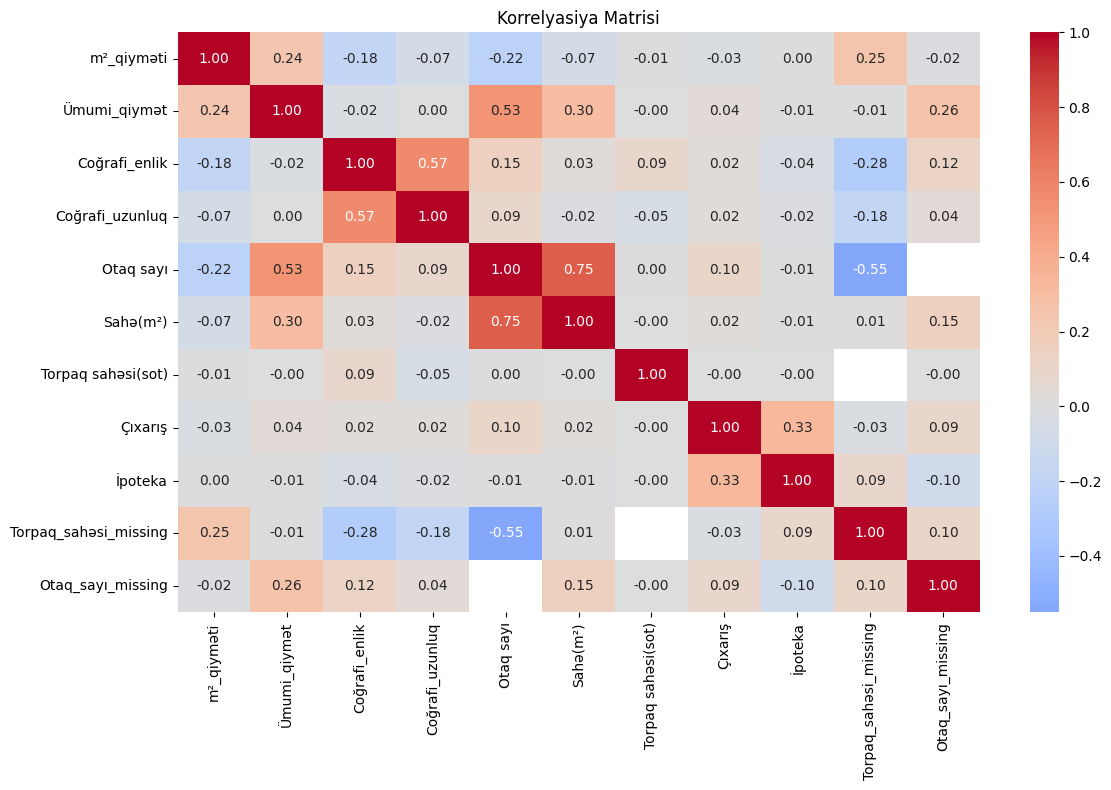

In [137]:
num_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelyasiya Matrisi")
plt.tight_layout()
plt.show()

Ümumi_qiymət və m²_qiyməti arasında güclü müsbət əlaqə (r=0.884), Otaq sayı və Sahə(m²) arasında isə güclü müsbət əlaqə (r=0.753) mövcuddur. Ümumi_qiymət ilə Otaq sayı və Sahə(m²) arasındakı əlaqə zəif olmuşdur (müvafiq olaraq r=0.077 və r=0.061). m²_qiyməti target dəyişəndən törədildiyi üçün data leakage riskinin qarşısını almaq məqsədilə modeldən çıxarılmalıdır. Digər dəyişənlər arasında əsasən zəif xətti əlaqələr müşahidə edilmişdir.

## Train/Test bölgüsü

In [138]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Ümumi_qiymət", "m²_qiyməti", "Valyuta"])
y = df["Ümumi_qiymət"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data leakage riskinin qarşısını almaq məqsədilə train/test bölgüsünü preprocessing əməliyyatlarından əvvəl həyata keçirdik. Datasetin 20%'ni test üçün saxlayıb, 80%'ni isə modelə öyrənməsi üçün veririk.

Kateqorik və numerik dəyərləri müəyyən edək:

In [139]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric sütunlar: {numeric_features}")
print(f"\nCategorical sütunlar: {categorical_features}")

Numeric sütunlar: ['Coğrafi_enlik', 'Coğrafi_uzunluq', 'Otaq sayı', 'Sahə(m²)', 'Torpaq sahəsi(sot)', 'Çıxarış', 'İpoteka', 'Torpaq_sahəsi_missing', 'Otaq_sayı_missing']

Categorical sütunlar: ['Məkan', 'Şəhər', 'Sahibin_statusu', 'Agentliyin_adı', 'Agentliyin_növü', 'Binanın növü', 'Kateqoriya', 'Mərtəbə', 'Təmir']


In [140]:
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

Modelə daxil edilməzdən əvvəl kateqorik sütunlarda fərqli məlumat tiplərinin qarışmasının qarşısını almaq üçün bütün kateqorik dəyişənlər string tipinə çevirək. Bu addım xüsusilə OneHotEncoder zamanı yarana biləcək tip uyğunsuzluğu xətalarının qarşısını almaq və məlumatların vahid formatda emal olunmasını təmin etmək məqsədi daşıyır.


In [141]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Preprocessing mərhələsində ColumnTransformer istifadə edilərək numerik və kateqorik dəyişənlər fərqli şəkildə emal edildi. Numerik dəyərlər StandardScaler vasitəsilə standartlaşdırıldı. Kateqorik dəyərlər isə OneHotEncoder ilə ədədi formata çevrilmişdir. Digər ikili (binary) dəyərlər əlavə emal olunmadan remainder="passthrough" vasitəsilə olduğu kimi modelə ötürüldü.

In [142]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

Qiymət proqnozlaşdırılması üçün xətti əlaqələri qiymətləndirmək məqsədilə Linear Regression, qeyri-xətti əlaqələri və mürəkkəb qarşılıqlı təsirləri modelləşdirmək üçün Random Forest Regressor və Gradient Boosting Regressor seçilmişdir. Datasetdə mövcud olan NaN dəyərlər isə modellərdən əvvəl preprocessing mərhələsində imputasiya ediləcəkdir.

In [143]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

Hər model üçün vahid Pipeline yaratdıq. Pipeline daxilində əvvəlcə preprocessing tətbiq edilir, daha sonra uyğun model qurulur. Beləliklə, çatışmayan dəyərlərin doldurulması, kodlaşdırma və standartlaşdırma bütün modellər üçün eyni qaydada həyata keçirilir.

In [144]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

Modelərin müqayisəsini obyektiv şəkildə aparmaq üçün 5-fold Cross-Validation tətbiq edildi. Modellərin performansı bütün modellər üçün eyni olmaqla MAE, RMSE və R² metrikləri əsasında qiymətləndirildi. Bu yanaşma modellərin eyni şərtlər altında müqayisə edilməsinə imkan vermişdir.

In [145]:
results = []

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "MAE": -scores["test_MAE"].mean(),
        "MAE_std": scores["test_MAE"].std(),
        "RMSE": -scores["test_RMSE"].mean(),
        "RMSE_std": scores["test_RMSE"].std(),
        "R²": scores["test_R2"].mean(),
        "R²_std": scores["test_R2"].std()
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MAE_std,RMSE,RMSE_std,R²,R²_std
0,Linear Regression,169631.311735,3083.337717,619392.321562,66451.666246,0.321679,0.048928
1,Random Forest,60753.531192,1403.440034,343135.795326,43531.502560,0.790878,0.032480
2,Gradient Boosting,88328.441359,1839.329550,372116.598273,38645.028927,0.753358,0.035209


Linear Regression ən zəif nəticəni göstərmişdir. Modelin orta MAE göstəricisi 169,631 AZN, RMSE göstəricisi 619,392 AZN, R² göstəricisi isə 0.322 olmuşdur. Bu nəticə qiymət ilə xüsusiyyətlər arasındakı əlaqələrin yalnız xətti formada izah edilməsinin kifayət etmədiyini göstərir.

Gradient Boosting Linear Regression ilə müqayisədə daha yaxşı nəticə vermişdir. Model üzrə orta MAE 88,328 AZN, RMSE 372,117 AZN, R² isə 0.753 olmuşdur. Bu, qeyri-xətti əlaqələrin modelləşdirilməsinin proqnoz keyfiyyətini əhəmiyyətli dərəcədə artırdığını göstərir.

Ən yaxşı nəticə Random Forest modelində əldə edilmişdir. Modelin orta MAE göstəricisi 60,754 AZN, RMSE göstəricisi 343,136 AZN, R² göstəricisi isə 0.791 olmuşdur. Yəni model test edilməmiş CV məlumatları üzərində qiymət dəyişkənliyinin təxminən 79.1%-ni izah edə bilmişdir. Eyni zamanda, Random Forest-ın həm MAE, həm də RMSE göstəricilərinin digər iki modeldən aşağı olması proqnoz səhvlərinin daha az olduğunu göstərir.

Fold-lar üzrə standart sapmalar da nəzərə alındıqda Random Forest üçün RMSE_std = 43,532 AZN və R²_std = 0.032 olmuşdur. Bu göstəricilər modelin müxtəlif fold-larda nisbətən stabil nəticə verdiyini göstərir. Nəticə olaraq, ilkin model müqayisəsində Random Forest ən uğurlu model seçilmişdir.

In [149]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": [1.0, "sqrt"]
}

Random Forest modelinin ən yaxşı parametrlərini tapmaq üçün axtarış sahəsi müəyyən edilir. Modelin bütün parametrlərini sabit saxlamaq əvəzinə, müxtəlif variantları sınayaraq hansı kombinasiyanın daha yaxşı nəticə verdiyini müəyyən etmək istəyirik.

In [150]:
rf_pipeline = pipelines["Random Forest"]

rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=8,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=2,
    verbose=1
)

rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Coğrafi_enlik',
                                                                                'Coğrafi_uzunluq',
                                                                                'Otaq '
                                                                                'sayı',
                                                                                'Sahə(m²)',
                                                                                'Torpaq '
                                                                                'sahəsi(sot)',
                                                                                'Çıxarış',
                                                                                'İpoteka',
                                                                                'Torpaq_...
                                                                                'Kateqoriya',
                                                                                'Mərtəbə',
                                                                                'Təmir'])])),
                                             ('model',
                                              RandomForestRegressor(max_depth=20,
                                                                    n_estimators=50,
                                                                    n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=8, n_jobs=2,
                   param_distributions={'model__max_depth': [10, 20],
                                        'model__max_features': [1.0, 'sqrt'],
                                        'model__min_samples_leaf': [1, 2],
                                        'model__n_estimators': [50, 100]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [151]:
print("Ən yaxşı parametrlər:")
print(rf_random.best_params_)

print("\nƏn yaxşı CV RMSE:")
print(-rf_random.best_score_)

Ən yaxşı parametrlər:
{'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 20}

Ən yaxşı CV RMSE:
340168.87828727794


RandomizedSearchCV vasitəsilə Random Forest modelinin hyperparameter tuning prosesi həyata keçirilmişdir. Axtarış nəticəsində ən yaxşı parametr kombinasiyası n_estimators=100, max_depth=20, min_samples_leaf=1 və max_features=1.0 olaraq müəyyən edilmişdir. Bu parametrlərlə modelin 5-fold Cross-Validation üzrə orta RMSE göstəricisi 340,168 AZN olmuşdur. İlkin Random Forest modelində əldə edilən 343,136 AZN RMSE ilə müqayisədə tuning nəticəsində model performansında cüzi yaxşılaşma əldə edilmişdir. Buna əsasən tuning edilmiş Random Forest yekun model kimi seçilmişdir.

In [153]:
final_model = rf_random.best_estimator_

Bu model artıq tuning zamanı müəyyən edilmiş ən yaxşı parametrlərlə qurulub.

In [154]:
y_test_pred = final_model.predict(X_test)

In [155]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test MAE: {test_mae:.2f} AZN")
print(f"Test RMSE: {test_rmse:.2f} AZN")
print(f"Test R²: {test_r2:.4f}")

Test MAE: 57079.20 AZN
Test RMSE: 265691.66 AZN
Test R²: 0.8745


Yekun model hyperparameter tuning mərhələsindən sonra seçilmiş Random Forest modeli olmuşdur. Model yalnız əvvəlcədən ayrılmış test datasetində bir dəfə qiymətləndirilmişdir. Test nəticələrinə əsasən modelin MAE göstəricisi 57,079.20 AZN, RMSE göstəricisi 265,691.66 AZN, R² göstəricisi isə 0.8745 olmuşdur. R² nəticəsi modelin daşınmaz əmlak qiymətlərindəki dəyişkənliyin təxminən 87.45%-ni izah etdiyini göstərir. MAE nəticəsinə əsasən model test məlumatlarında qiymətləri orta hesabla təxminən 57 min AZN xəta ilə proqnozlaşdırmışdır.

In [156]:
import joblib

joblib.dump(final_model, "final_model.pkl")

['final_model.pkl']

Yekun hyperparameter tuning edilmiş Random Forest modeli joblib kitabxanasından istifadə edərək final_model.pkl faylı şəklində saxladıq.

# Nəticə


Bu layihə çərçivəsində daşınmaz əmlak elanları əsasında əmlakın **ümumi qiymətinin proqnozlaşdırılması** üçün maşın öyrənməsi modeli hazırlanmışdır. Məlumatların ilkin analizi və təmizlənməsi aparılmış, çatışmayan dəyərlər nəzərə alınmış və model üçün uyğun xüsusiyyətlər müəyyən edilmişdir. Daha sonra Linear Regression, Random Forest və Gradient Boosting modelləri eyni qiymətləndirmə metodologiyası ilə müqayisə edilmişdir.

Müqayisə nəticəsində ən yaxşı performansı **Random Forest** modeli göstərmiş və onun hiperparametrləri `RandomizedSearchCV` vasitəsilə optimallaşdırılmışdır. Yekun model ayrılmış test datasetində yalnız bir dəfə qiymətləndirilmişdir. Test nəticələrinə əsasən modelin **MAE göstəricisi 57,079.20 AZN**, **RMSE göstəricisi 265,691.66 AZN**, **R² göstəricisi isə 0.8745** olmuşdur. Bu nəticə modelin əmlak qiymətlərindəki dəyişkənliyin təxminən **87.45%-ni izah edə bildiyini** göstərir.

Əldə olunan nəticələr göstərir ki, model daşınmaz əmlakın qiymətləndirilməsi prosesini dəstəkləmək, qiymətlərin ilkin təxminini avtomatlaşdırmaq və çoxsaylı elanların daha sürətli analiz edilməsinə kömək edə bilər. Bununla belə, xüsusilə yüksək qiymətli əmlaklarda böyük proqnoz xətalarının mövcudluğu nəzərə alınmalıdır. Gələcəkdə daha aktual bazar məlumatlarının əlavə edilməsi, coğrafi məlumatların daha detallı istifadəsi və modelin mütəmadi olaraq yenilənməsi proqnozların dəqiqliyini daha da artırmağa imkan verə bilər.

Yekun olaraq, hazırlanmış model daşınmaz əmlak bazarının analizi və qiymətləndirmə prosesinin məlumat əsaslı şəkildə dəstəklənməsi üçün praktik potensiala malikdir.